# Statistiques Descriptives — Évaluation causale des domestiques
## Optimisation du calendrier en cyclisme professionnel (2018–2025)

**Objectif :** Explorer les données avant toute modélisation. Ce notebook répond aux questions :
- Comment se distribue l'outcome (points UCI équipe) ?
- Quelle est la structure du traitement (sélection) ?
- Le biais de sélection est-il visible dans les données ?
- Quels confondants sont les plus importants ?

**Ces statistiques sont purement descriptives — aucune causalité n'est interprétée ici.**

---
**Structure :**
1. Chargement & aperçu global du dataset
2. Distribution de l'outcome `pts_uci_equipe_stage` (Y)
3. Le traitement `selected` (T) — taux de sélection
4. Biais de sélection — cœur du problème
5. Profil des courses (confondants X)
6. Stage clusters — typologies de courses
7. Forme équipe & charge coureur
8. Vue par coureur — top contributeurs

## 0. Imports & Configuration

In [24]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.3f}'.format)

RIDER_DIR = Path('rider_data')
OUTCOME   = 'pts_uci_equipe_stage'
TREATMENT = 'selected'

VISMA_TEAMS = [
    'Team LottoNL-Jumbo', 'Jumbo-Visma',
    'Team Jumbo-Visma', 'Team Visma | Lease a Bike',
]
EQUIPE_LABEL = 'Team Visma | Lease a Bike (Jumbo-Visma)'

COLS_STATS = [
    'date', 'year', 'course', 'equipe', 'selected', 'statut', 'rang',
    'classification', 'stage_cluster', 'stage_cluster_label',
    'pts_uci_equipe_stage', 'pts_uci', 'pts_ratio',
    'distance_gpx_km', 'denivele_pos', 'altitude_max',
    'n_cols_hc', 'n_cols_cat1', 'gradient_last_1km', 'gradient_last_5km',
    'cobblestones_km', 'compacted_gravel_km', 'cobblestones_last_10km',
    'forme_equipe', 'n_races_30d', 'km_30d', 'max_pts',
    'startlist_quality', 'avg_temperature', 'won_how', 'leader_played',
]

# ── Palette couleurs (identique à Modele_Causal) ─────────────────────────────
C_BLUE   = '#2271B3'
C_ORANGE = '#E8824B'
C_RED    = '#D94F3D'
C_GRAY   = '#BDBDBD'
C_TEAL   = '#3BAAAA'
C_PURPLE = '#8B5EA6'
CLUSTER_COLORS = {
    '⏱️  CLM':            '#5B5B9B',
    '🟢  Plat/Sprint':    C_TEAL,
    '⛰️  Moy. montagne':  C_ORANGE,
    '🏔️  Haute montagne': C_PURPLE,
}

print('✅ Configuration chargée')
print(f'   Dossier rider_data : {RIDER_DIR}')
print(f'   Équipe cible       : {EQUIPE_LABEL}')
print(f'   Outcome (Y)        : {OUTCOME}')
print(f'   Traitement (T)     : {TREATMENT}')


✅ Configuration chargée
   Dossier rider_data : rider_data
   Équipe cible       : Team Visma | Lease a Bike (Jumbo-Visma)
   Outcome (Y)        : pts_uci_equipe_stage
   Traitement (T)     : selected


## 1. Chargement & aperçu global

On charge tous les coureurs de `riders_causal_inclus.csv`. Chaque ligne = une course × un coureur.

In [25]:
all_files = sorted(RIDER_DIR.glob('*.csv'))
print(f'Chargement de {len(all_files)} fichiers coureurs...')

chunks = []
for f in tqdm(all_files, desc='Lecture rider_data'):
    try:
        df = pd.read_csv(f, low_memory=False)
        df = df[[c for c in COLS_STATS if c in df.columns]]
        df['rider'] = f.stem
        chunks.append(df)
    except Exception:
        pass

df_all = pd.concat(chunks, ignore_index=True)
df_all['date']    = pd.to_datetime(df_all['date'], errors='coerce')
df_all['year']    = pd.to_numeric(df_all['year'],  errors='coerce')
df_all[OUTCOME]   = pd.to_numeric(df_all[OUTCOME], errors='coerce')

print(f'Dataset chargé : {len(df_all):,} lignes | {df_all["rider"].nunique():,} coureurs')
print(f'Années : {int(df_all["year"].min())} – {int(df_all["year"].max())}')
print(f'selected=1 : {(df_all[TREATMENT]==1).sum():,} | selected=0 : {(df_all[TREATMENT]==0).sum():,}')
print(f'leader_played disponible : {df_all["leader_played"].notna().sum():,} lignes' if 'leader_played' in df_all.columns else 'leader_played : non chargé')


Chargement de 5137 fichiers coureurs...


Lecture rider_data: 100%|██████████| 5137/5137 [00:18<00:00, 283.58it/s]


Dataset chargé : 2,506,196 lignes | 5,137 coureurs
Années : 2018 – 2025
selected=1 : 694,352 | selected=0 : 1,811,844
leader_played disponible : 2,467,271 lignes


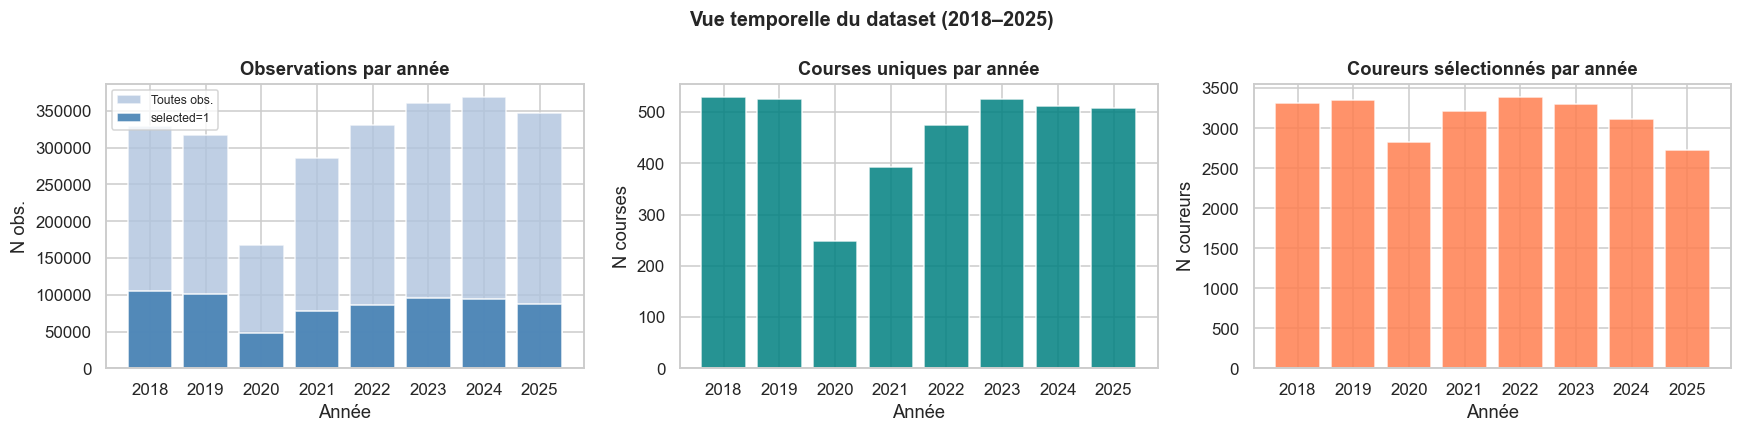

In [26]:
# ── Distribution temporelle ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Observations par année
obs_year = df_all.groupby('year').size()
sel_year = df_all[df_all[TREATMENT]==1].groupby('year').size()
ax = axes[0]
ax.bar(obs_year.index, obs_year.values, color='lightsteelblue', label='Toutes obs.', alpha=0.8)
ax.bar(sel_year.index, sel_year.values, color='steelblue',      label='selected=1',  alpha=0.9)
ax.set_title('Observations par année', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('N obs.')
ax.legend(fontsize=8)

# Courses uniques par année
courses_year = df_all.groupby('year')['course'].nunique()
ax = axes[1]
ax.bar(courses_year.index, courses_year.values, color='teal', alpha=0.85)
ax.set_title('Courses uniques par année', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('N courses')

# Coureurs actifs par année
riders_year = df_all[df_all[TREATMENT]==1].groupby('year')['rider'].nunique()
ax = axes[2]
ax.bar(riders_year.index, riders_year.values, color='coral', alpha=0.85)
ax.set_title('Coureurs sélectionnés par année', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('N coureurs')

plt.suptitle('Vue temporelle du dataset (2018–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Distribution de l'outcome Y = `pts_uci_equipe_stage`

L'outcome mesure la **performance collective de l'équipe** sur une étape. C'est ce qu'on cherche à optimiser en choisissant les bons coureurs.

Points clés à vérifier :
- La distribution est-elle zero-inflated ? (beaucoup d'étapes à 0 points)
- Faut-il transformer Y ? (log(1+Y) pour stabiliser la variance)
- Y varie-t-il selon le type de course ?

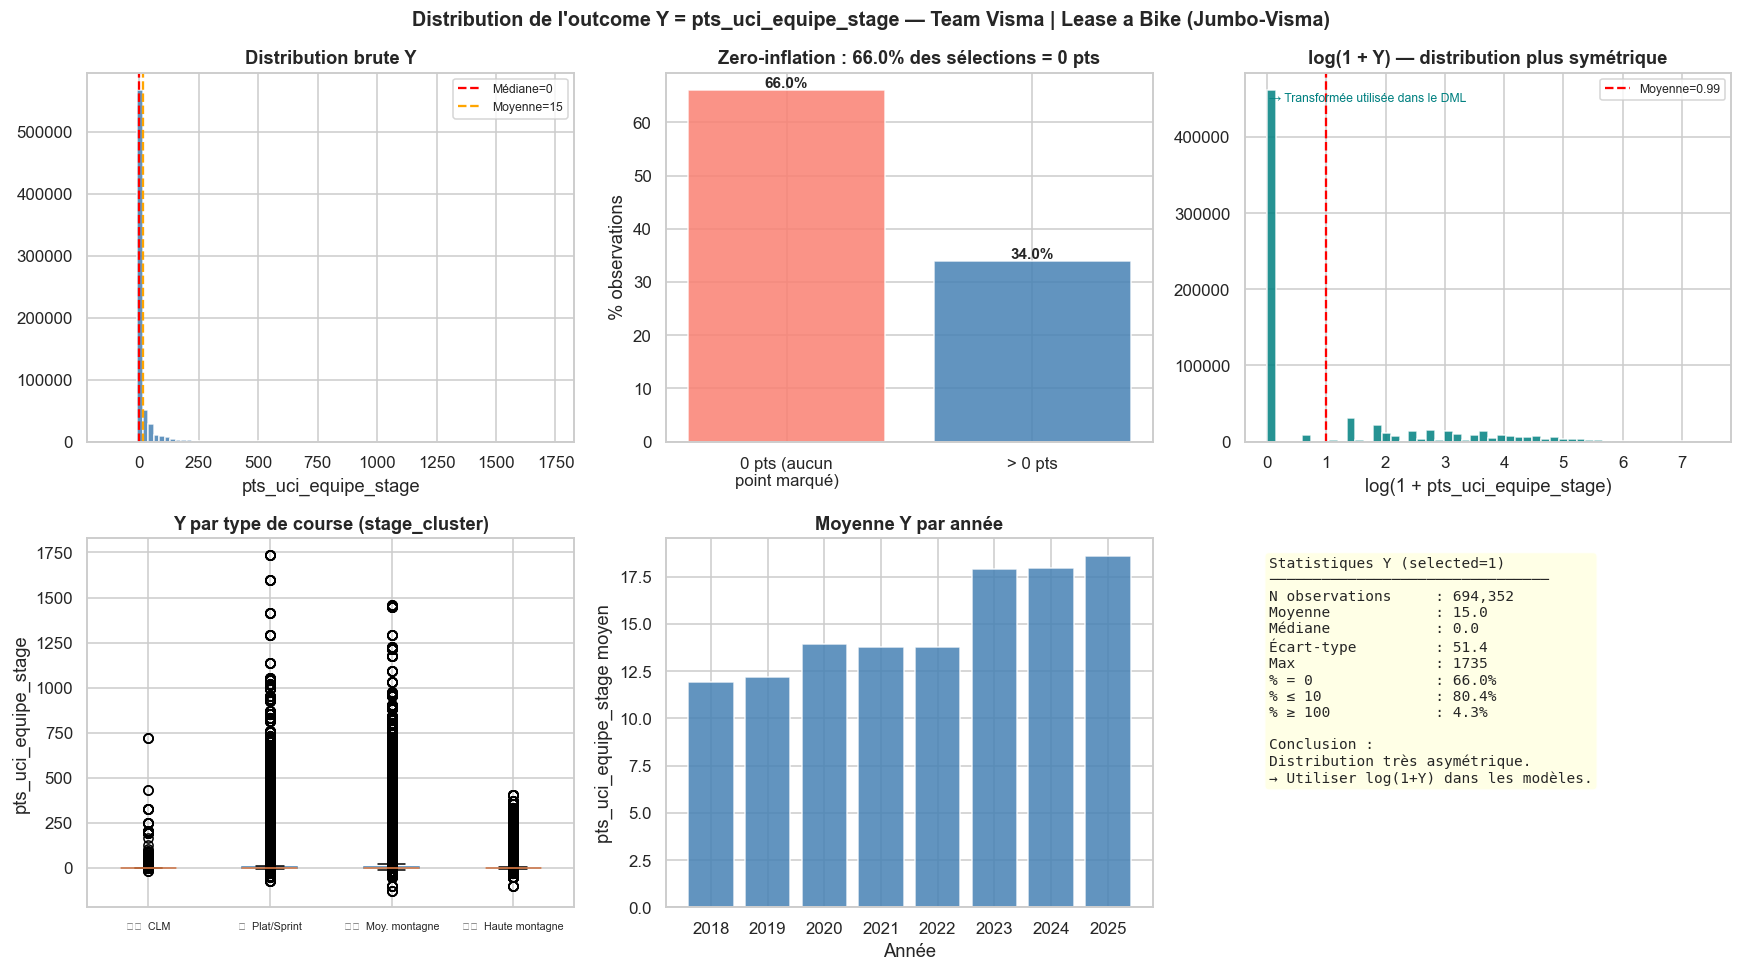

In [27]:
# Travailler uniquement sur les observations sélectionnées pour l'outcome
df_sel = df_all[df_all[TREATMENT] == 1].copy()
Y = df_sel[OUTCOME].dropna()
pct_zero = (Y == 0).mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Distribution brute — toutes valeurs
ax = axes[0,0]
ax.hist(Y, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(Y.median(), color='red',    linestyle='--', label=f'Médiane={Y.median():.0f}')
ax.axvline(Y.mean(),   color='orange', linestyle='--', label=f'Moyenne={Y.mean():.0f}')
ax.set_title('Distribution brute Y', fontweight='bold')
ax.set_xlabel('pts_uci_equipe_stage'); ax.legend(fontsize=8)

# Proportion zeros
ax = axes[0,1]
vals = [pct_zero, 100-pct_zero]
bars = ax.bar(['0 pts (aucun\npoint marqué)', '> 0 pts'], vals,
              color=['salmon', 'steelblue'], alpha=0.85, edgecolor='white')
ax.set_title(f'Zero-inflation : {pct_zero:.1f}% des sélections = 0 pts', fontweight='bold')
ax.set_ylabel('% observations')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v+0.5, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=10)

# Log-transformation
ax = axes[0,2]
Y_log = np.log1p(Y.clip(0))
ax.hist(Y_log, bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(Y_log.mean(), color='red', linestyle='--',
           label=f'Moyenne={Y_log.mean():.2f}')
ax.set_title('log(1 + Y) — distribution plus symétrique', fontweight='bold')
ax.set_xlabel('log(1 + pts_uci_equipe_stage)'); ax.legend(fontsize=8)
ax.text(0.05, 0.92, '→ Transformée utilisée dans le DML',
        transform=ax.transAxes, fontsize=8, color='teal')

# Y par stage_cluster
ax = axes[1,0]
if 'stage_cluster_label' in df_sel.columns:
    order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
    data_cl = [df_sel[df_sel['stage_cluster_label']==c][OUTCOME].dropna().values
               for c in order if c in df_sel['stage_cluster_label'].values]
    labels_cl = [c for c in order if c in df_sel['stage_cluster_label'].values]
    ax.boxplot(data_cl, labels=labels_cl, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='steelblue'))
    ax.set_title('Y par type de course (stage_cluster)', fontweight='bold')
    ax.set_ylabel('pts_uci_equipe_stage')
    ax.tick_params(axis='x', labelsize=7)

# Y par année
ax = axes[1,1]
y_year = df_sel.groupby('year')[OUTCOME].mean()
ax.bar(y_year.index, y_year.values, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title('Moyenne Y par année', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('pts_uci_equipe_stage moyen')

# Statistiques résumé
ax = axes[1,2]
ax.axis('off')
stats_text = (
    f'Statistiques Y (selected=1)\n'
    f'{"─"*32}\n'
    f'N observations     : {len(Y):,}\n'
    f'Moyenne            : {Y.mean():.1f}\n'
    f'Médiane            : {Y.median():.1f}\n'
    f'Écart-type         : {Y.std():.1f}\n'
    f'Max                : {Y.max():.0f}\n'
    f'% = 0              : {pct_zero:.1f}%\n'
    f'% ≤ 10             : {(Y<=10).mean()*100:.1f}%\n'
    f'% ≥ 100            : {(Y>=100).mean()*100:.1f}%\n'
    f'\nConclusion :\n'
    f'Distribution très asymétrique.\n'
    f'→ Utiliser log(1+Y) dans les modèles.'
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=9.5, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(f'Distribution de l\'outcome Y = pts_uci_equipe_stage — {EQUIPE_LABEL}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Le traitement T = `selected`

Le traitement est binaire : **1 = le coureur est dans l'équipe pour cette course**, 0 = il ne l'est pas.

Questions importantes :
- Les coureurs sont-ils sélectionnés également sur toutes les courses ?
- Y a-t-il des patterns de sélection par type de course ou par équipe ?
- Quelle est la variance intra-coureur dans le traitement (nécessaire pour le DML) ?

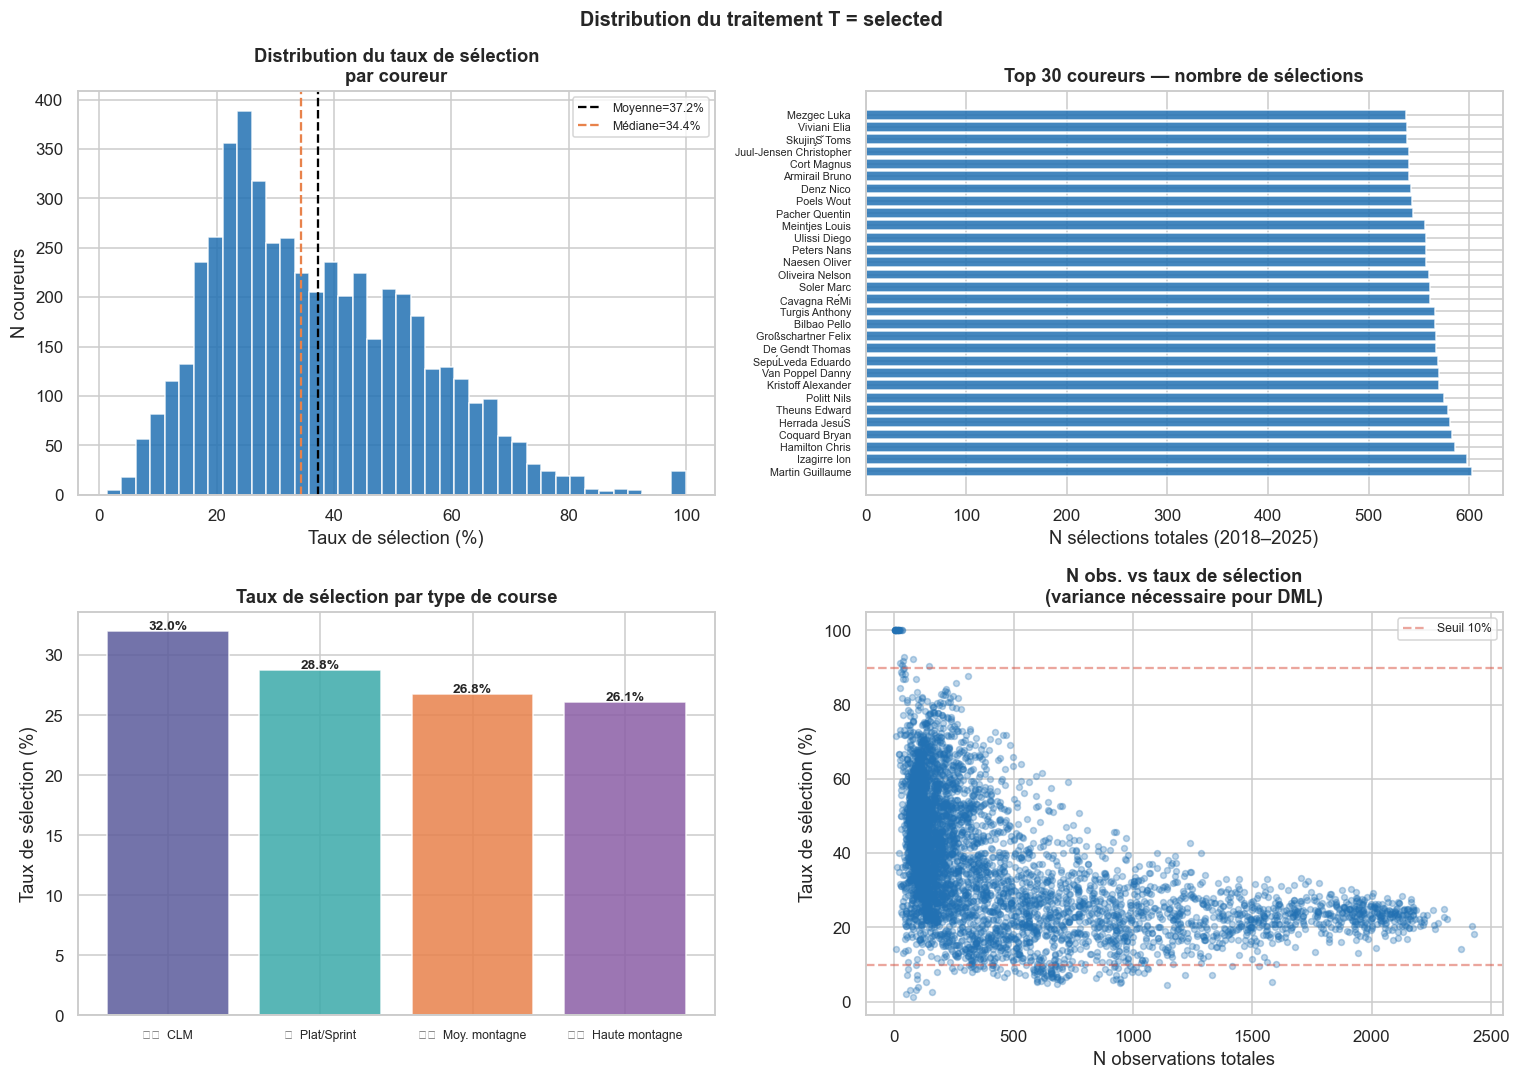

Coureurs avec < 5 sélections  : 15
Coureurs avec >= 20 sélections : 5006


In [28]:
rider_stats = df_all.groupby('rider').agg(
    n_obs      = (TREATMENT, 'count'),
    n_selected = (TREATMENT, 'sum'),
    taux_sel   = (TREATMENT, 'mean'),
    n_courses  = ('course', 'nunique'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(rider_stats['taux_sel'] * 100, bins=40, color=C_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(rider_stats['taux_sel'].mean() * 100, color='black', linestyle='--',
           label=f'Moyenne={rider_stats["taux_sel"].mean()*100:.1f}%')
ax.axvline(rider_stats['taux_sel'].median() * 100, color=C_ORANGE, linestyle='--',
           label=f'Médiane={rider_stats["taux_sel"].median()*100:.1f}%')
ax.set_title('Distribution du taux de sélection\npar coureur', fontweight='bold')
ax.set_xlabel('Taux de sélection (%)')
ax.set_ylabel('N coureurs')
ax.legend(fontsize=8)

ax = axes[0, 1]
top30 = rider_stats.nlargest(30, 'n_selected')
ax.barh(range(len(top30)), top30['n_selected'].values, color=C_BLUE, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['rider'].str.replace('_', ' ').str.title(), fontsize=7)
ax.set_xlabel('N sélections totales (2018–2025)')
ax.set_title('Top 30 coureurs — nombre de sélections', fontweight='bold')

ax = axes[1, 0]
if 'stage_cluster_label' in df_all.columns:
    order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
    taux_cl = df_all.groupby('stage_cluster_label')[TREATMENT].mean() * 100
    taux_cl = taux_cl.reindex([c for c in order if c in taux_cl.index])
    cols_cl = [CLUSTER_COLORS.get(c, C_GRAY) for c in taux_cl.index]
    ax.bar(range(len(taux_cl)), taux_cl.values, color=cols_cl, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(taux_cl)))
    ax.set_xticklabels(taux_cl.index, fontsize=8)
    ax.set_ylabel('Taux de sélection (%)')
    ax.set_title('Taux de sélection par type de course', fontweight='bold')
    for i, v in enumerate(taux_cl.values):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax = axes[1, 1]
ax.scatter(rider_stats['n_obs'], rider_stats['taux_sel'] * 100,
           alpha=0.3, s=15, color=C_BLUE)
ax.axhline(10, color=C_RED, linestyle='--', alpha=0.5, label='Seuil 10%')
ax.axhline(90, color=C_RED, linestyle='--', alpha=0.5)
ax.set_xlabel('N observations totales')
ax.set_ylabel('Taux de sélection (%)')
ax.set_title('N obs. vs taux de sélection\n(variance nécessaire pour DML)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Distribution du traitement T = selected', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Coureurs avec < 5 sélections  : {(rider_stats["n_selected"] < 5).sum()}')
print(f'Coureurs avec >= 20 sélections : {(rider_stats["n_selected"] >= 20).sum()}')


## 4. Biais de sélection — Le cœur du problème

**C'est ici que se justifie l'approche causale.**

Si on compare naïvement les points équipe quand un coureur est présent vs absent, on mélange :
1. L'**effet causal** du coureur (ce qu'on veut estimer)
2. L'**effet du type de course** : les équipes envoient leurs meilleurs coureurs sur les plus grandes courses, qui rapportent naturellement plus de points

→ L'effet naïf (brut) surestime les bons coureurs et sous-estime les domestiques purs.

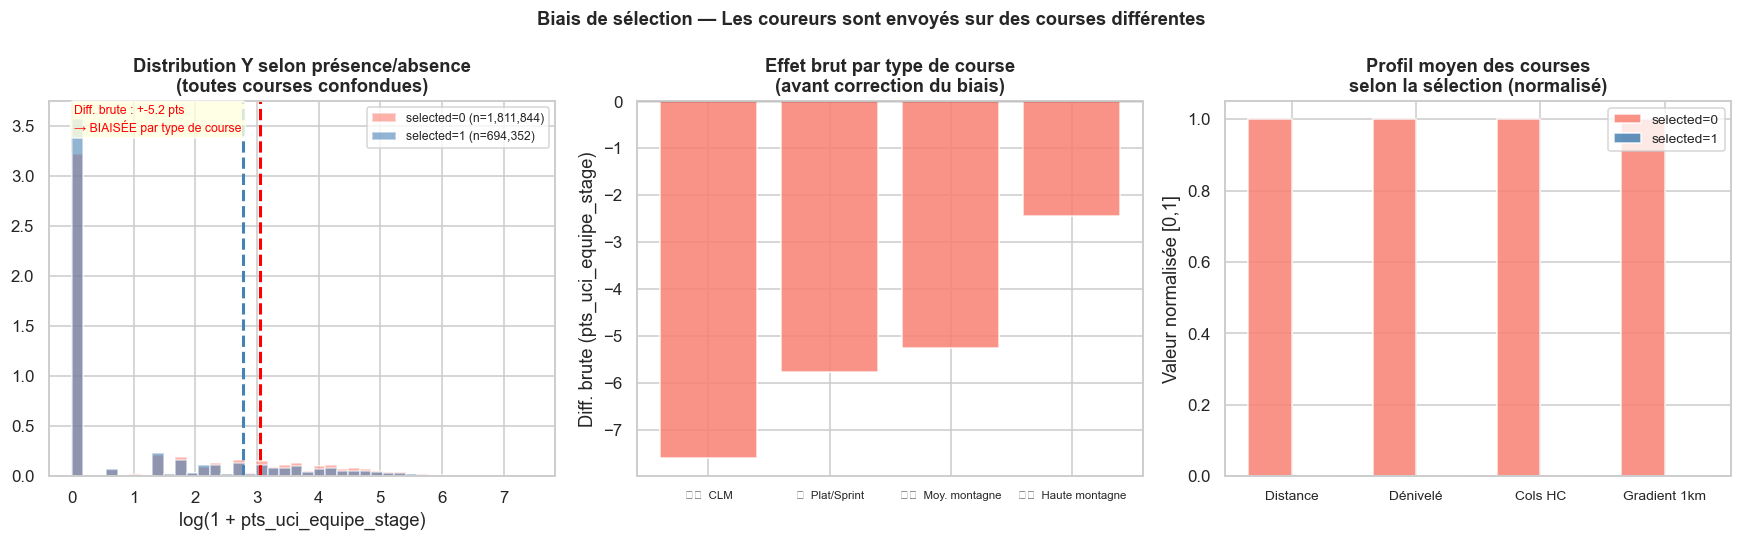

In [29]:
# ── Effet brut global ──────────────────────────────────────────────────────
y_present = df_all[df_all[TREATMENT]==1][OUTCOME].dropna()
y_absent  = df_all[df_all[TREATMENT]==0][OUTCOME].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Comparaison présence/absence — toutes courses
ax = axes[0]
ax.hist(np.log1p(y_absent.clip(0)),  bins=40, alpha=0.6, color='salmon',
        label=f'selected=0 (n={len(y_absent):,})', density=True)
ax.hist(np.log1p(y_present.clip(0)), bins=40, alpha=0.6, color='steelblue',
        label=f'selected=1 (n={len(y_present):,})', density=True)
ax.axvline(np.log1p(y_absent.mean()),  color='red',    linestyle='--', linewidth=2)
ax.axvline(np.log1p(y_present.mean()), color='steelblue', linestyle='--', linewidth=2)
ax.set_xlabel('log(1 + pts_uci_equipe_stage)')
ax.set_title('Distribution Y selon présence/absence\n(toutes courses confondues)', fontweight='bold')
ax.legend(fontsize=8)
diff_brut = y_present.mean() - y_absent.mean()
ax.text(0.05, 0.92, f'Diff. brute : +{diff_brut:.1f} pts\n→ BIAISÉE par type de course',
        transform=ax.transAxes, fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Diff. brute par stage_cluster
ax = axes[1]
if 'stage_cluster_label' in df_all.columns:
    order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
    diffs = {}
    for cl in order:
        sub = df_all[df_all['stage_cluster_label'] == cl]
        m1 = sub[sub[TREATMENT]==1][OUTCOME].mean()
        m0 = sub[sub[TREATMENT]==0][OUTCOME].mean()
        diffs[cl] = m1 - m0
    colors_d = ['steelblue' if v > 0 else 'salmon' for v in diffs.values()]
    ax.bar(range(len(diffs)), list(diffs.values()),
           color=colors_d, edgecolor='white', alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(diffs)))
    ax.set_xticklabels(list(diffs.keys()), fontsize=7.5)
    ax.set_ylabel('Diff. brute (pts_uci_equipe_stage)')
    ax.set_title('Effet brut par type de course\n(avant correction du biais)', fontweight='bold')

# Profil des courses sélectionnées vs non-sélectionnées
ax = axes[2]
features_profil = ['distance_gpx_km', 'denivele_pos', 'n_cols_hc', 'gradient_last_1km']
features_profil = [f for f in features_profil if f in df_all.columns]
profil = df_all.groupby(TREATMENT)[features_profil].mean()
profil_norm = (profil - profil.min()) / (profil.max() - profil.min() + 1e-9)
x = np.arange(len(features_profil))
w = 0.35
ax.bar(x - w/2, profil_norm.loc[0].values, w, label='selected=0', color='salmon',   alpha=0.85)
ax.bar(x + w/2, profil_norm.loc[1].values, w, label='selected=1', color='steelblue', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Distance', 'Dénivelé', 'Cols HC', 'Gradient 1km'], fontsize=9)
ax.set_ylabel('Valeur normalisée [0,1]')
ax.set_title('Profil moyen des courses\nselon la sélection (normalisé)', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Biais de sélection — Les coureurs sont envoyés sur des courses différentes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

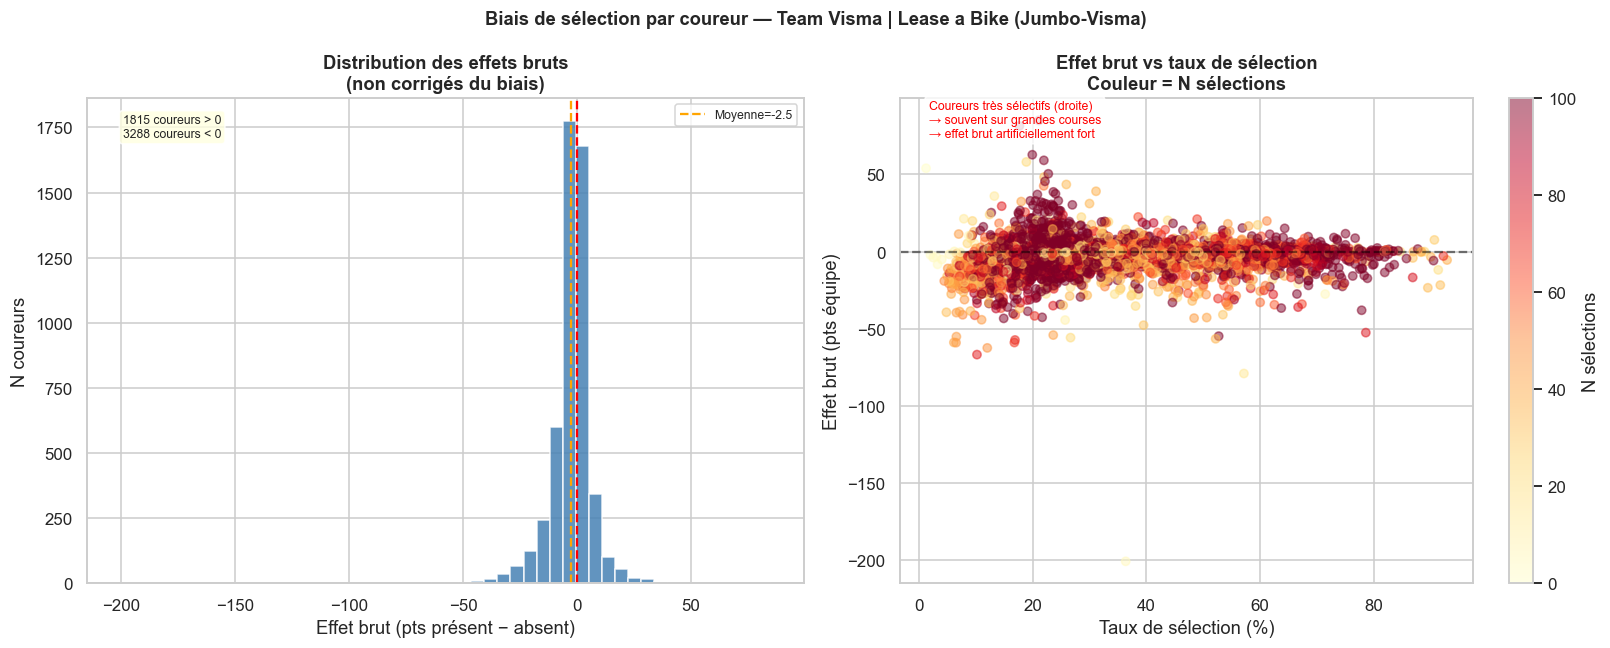

Top 10 effets bruts positifs (potentiellement surestimés) :
               rider   n_sel  taux_sel  Y_present  Y_absent  effet_brut
       van_aert_wout 361.000     0.210    116.060    31.020      85.040
van_der_poel_mathieu 284.000     0.180    109.530    28.040      81.500
      pogačar_tadej 410.000     0.200     99.510    36.720      62.790
        benoot_tiesj 422.000     0.220     88.920    29.750      59.170
         leung_ka_yu  24.000     0.190     60.330     2.200      58.130
  altansukh_altanzul   1.000     0.010     55.000     0.960      54.040
   vermeersch_gianni 353.000     0.230     80.500    30.050      50.450
        guerra_sandi  35.000     0.220     52.540     4.200      48.340
van_hooydonck_nathan 306.000     0.220     72.410    26.850      45.560
     leung_chun_wing  35.000     0.260     44.660     1.120      43.540


In [30]:
# ── Biais par coureur — illustration sur cas concrets ──────────────────────
effets = df_all.groupby('rider').apply(lambda g: pd.Series({
    'n_sel':     (g[TREATMENT]==1).sum(),
    'n_nonsel':  (g[TREATMENT]==0).sum(),
    'taux_sel':  g[TREATMENT].mean(),
    'Y_present': g[g[TREATMENT]==1][OUTCOME].mean(),
    'Y_absent':  g[g[TREATMENT]==0][OUTCOME].mean(),
})).reset_index()
effets['effet_brut'] = effets['Y_present'] - effets['Y_absent']
effets = effets.dropna(subset=['effet_brut'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution des effets bruts
ax = axes[0]
ax.hist(effets['effet_brut'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(effets['effet_brut'].mean(), color='orange', linestyle='--',
           label=f'Moyenne={effets["effet_brut"].mean():.1f}')
ax.set_xlabel('Effet brut (pts présent − absent)')
ax.set_ylabel('N coureurs')
ax.set_title('Distribution des effets bruts\n(non corrigés du biais)', fontweight='bold')
ax.legend(fontsize=8)
ax.text(0.05, 0.92,
        f'{(effets["effet_brut"] > 0).sum()} coureurs > 0\n'
        f'{(effets["effet_brut"] < 0).sum()} coureurs < 0',
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Effet brut vs taux de sélection
ax = axes[1]
sc = ax.scatter(effets['taux_sel']*100, effets['effet_brut'],
                alpha=0.5, s=30, c=effets['n_sel'], cmap='YlOrRd', vmin=0, vmax=100)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Taux de sélection (%)')
ax.set_ylabel('Effet brut (pts équipe)')
ax.set_title('Effet brut vs taux de sélection\nCouleur = N sélections', fontweight='bold')
plt.colorbar(sc, ax=ax, label='N sélections')
ax.text(0.05, 0.92,
        'Coureurs très sélectifs (droite)\n→ souvent sur grandes courses\n→ effet brut artificiellement fort',
        transform=ax.transAxes, fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'Biais de sélection par coureur — {EQUIPE_LABEL}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 effets bruts positifs (potentiellement surestimés) :')
print(effets.nlargest(10, 'effet_brut')[['rider','n_sel','taux_sel','Y_present','Y_absent','effet_brut']].round(2).to_string(index=False))

## 5. Profil des courses — Confondants X

Les **confondants** sont les variables qui influencent à la fois :
- La probabilité d'être sélectionné (T)
- L'outcome équipe (Y)

Ce sont les variables à contrôler dans le DML pour isoler l'effet causal.

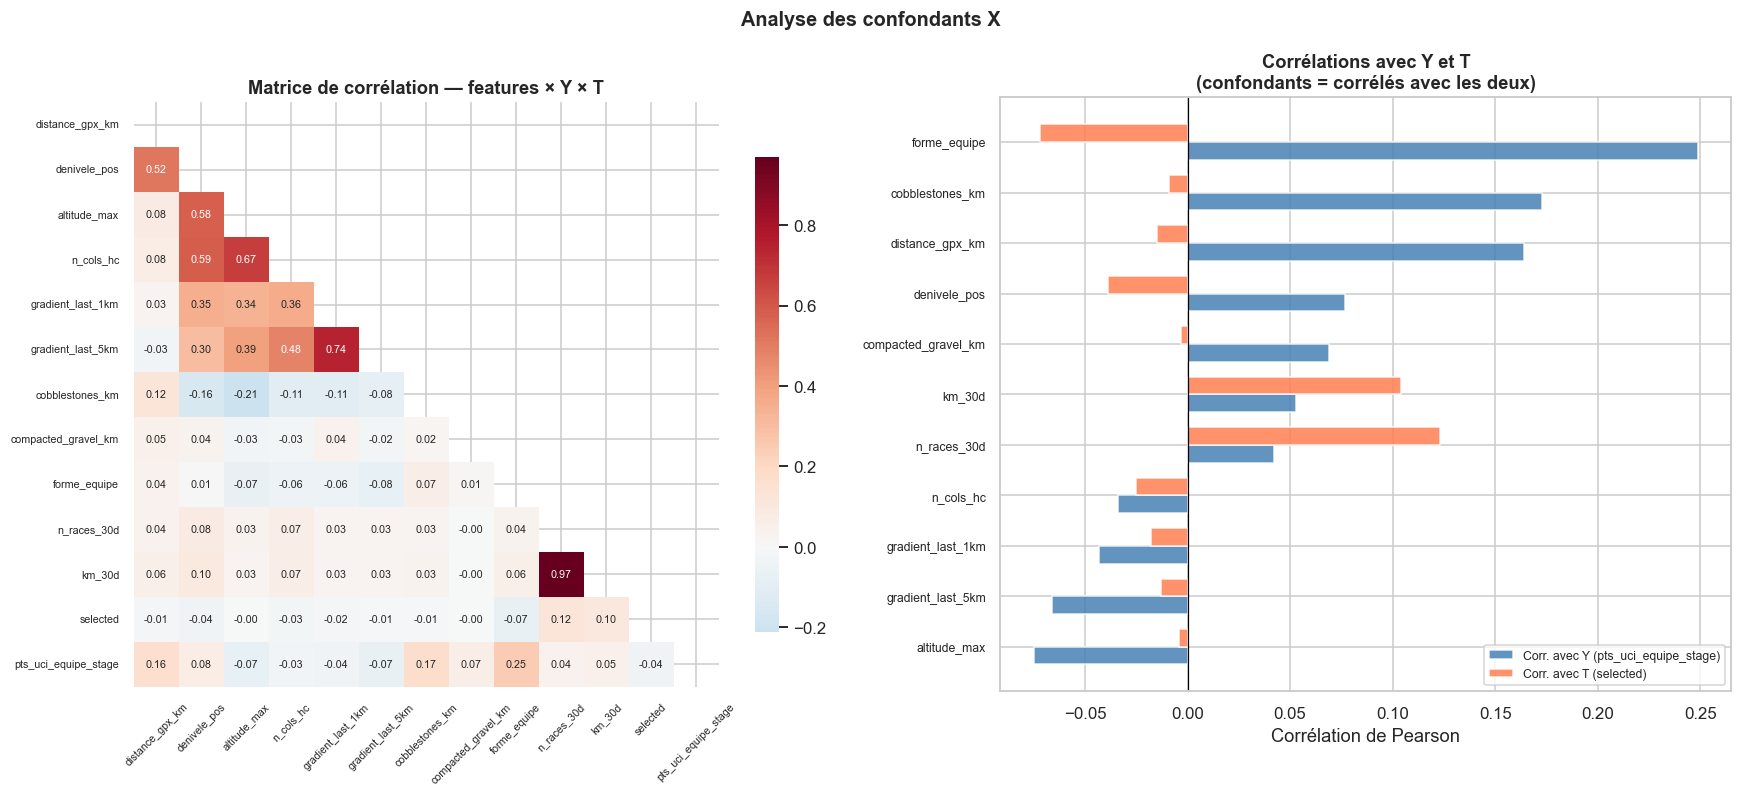

Corrélations avec Y (pts_uci_equipe_stage) :
forme_equipe           0.249
cobblestones_km        0.173
distance_gpx_km        0.164
denivele_pos           0.077
compacted_gravel_km    0.069
km_30d                 0.053
n_races_30d            0.042
n_cols_hc             -0.034
selected              -0.041
gradient_last_1km     -0.043
gradient_last_5km     -0.066
altitude_max          -0.075


In [31]:
# ── Corrélations des features avec Y et T ──────────────────────────────────
features_conf = [
    'distance_gpx_km', 'denivele_pos', 'altitude_max',
    'n_cols_hc', 'gradient_last_1km', 'gradient_last_5km',
    'cobblestones_km', 'compacted_gravel_km',
    'forme_equipe', 'n_races_30d', 'km_30d',
    TREATMENT, OUTCOME
]
features_conf = [f for f in features_conf if f in df_all.columns]

df_conf = df_all[features_conf].dropna(how='all')
corr = df_conf.corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap complète
ax = axes[0]
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, mask=mask, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
ax.set_title('Matrice de corrélation — features × Y × T', fontweight='bold')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7)

# Corrélation avec Y et T séparément
ax = axes[1]
corr_y = corr[OUTCOME].drop([OUTCOME, TREATMENT]).sort_values()
corr_t = corr[TREATMENT].drop([OUTCOME, TREATMENT]).reindex(corr_y.index)

x = np.arange(len(corr_y))
w = 0.35
ax.barh(x - w/2, corr_y.values, w, label=f'Corr. avec Y ({OUTCOME})',
        color='steelblue', alpha=0.85, edgecolor='white')
ax.barh(x + w/2, corr_t.values, w, label=f'Corr. avec T (selected)',
        color='coral', alpha=0.85, edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(corr_y.index, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson')
ax.set_title('Corrélations avec Y et T\n(confondants = corrélés avec les deux)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Analyse des confondants X', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Corrélations avec Y (pts_uci_equipe_stage) :')
print(corr[OUTCOME].drop(OUTCOME).sort_values(ascending=False).to_string())

## 6. Stage Clusters — Typologies de courses

Les 4 clusters de courses permettent de **stratifier l'analyse** et d'expliquer l'hétérogénéité des effets causaux (CATE). Un coureur peut apporter beaucoup en plat/sprint et rien en haute montagne.

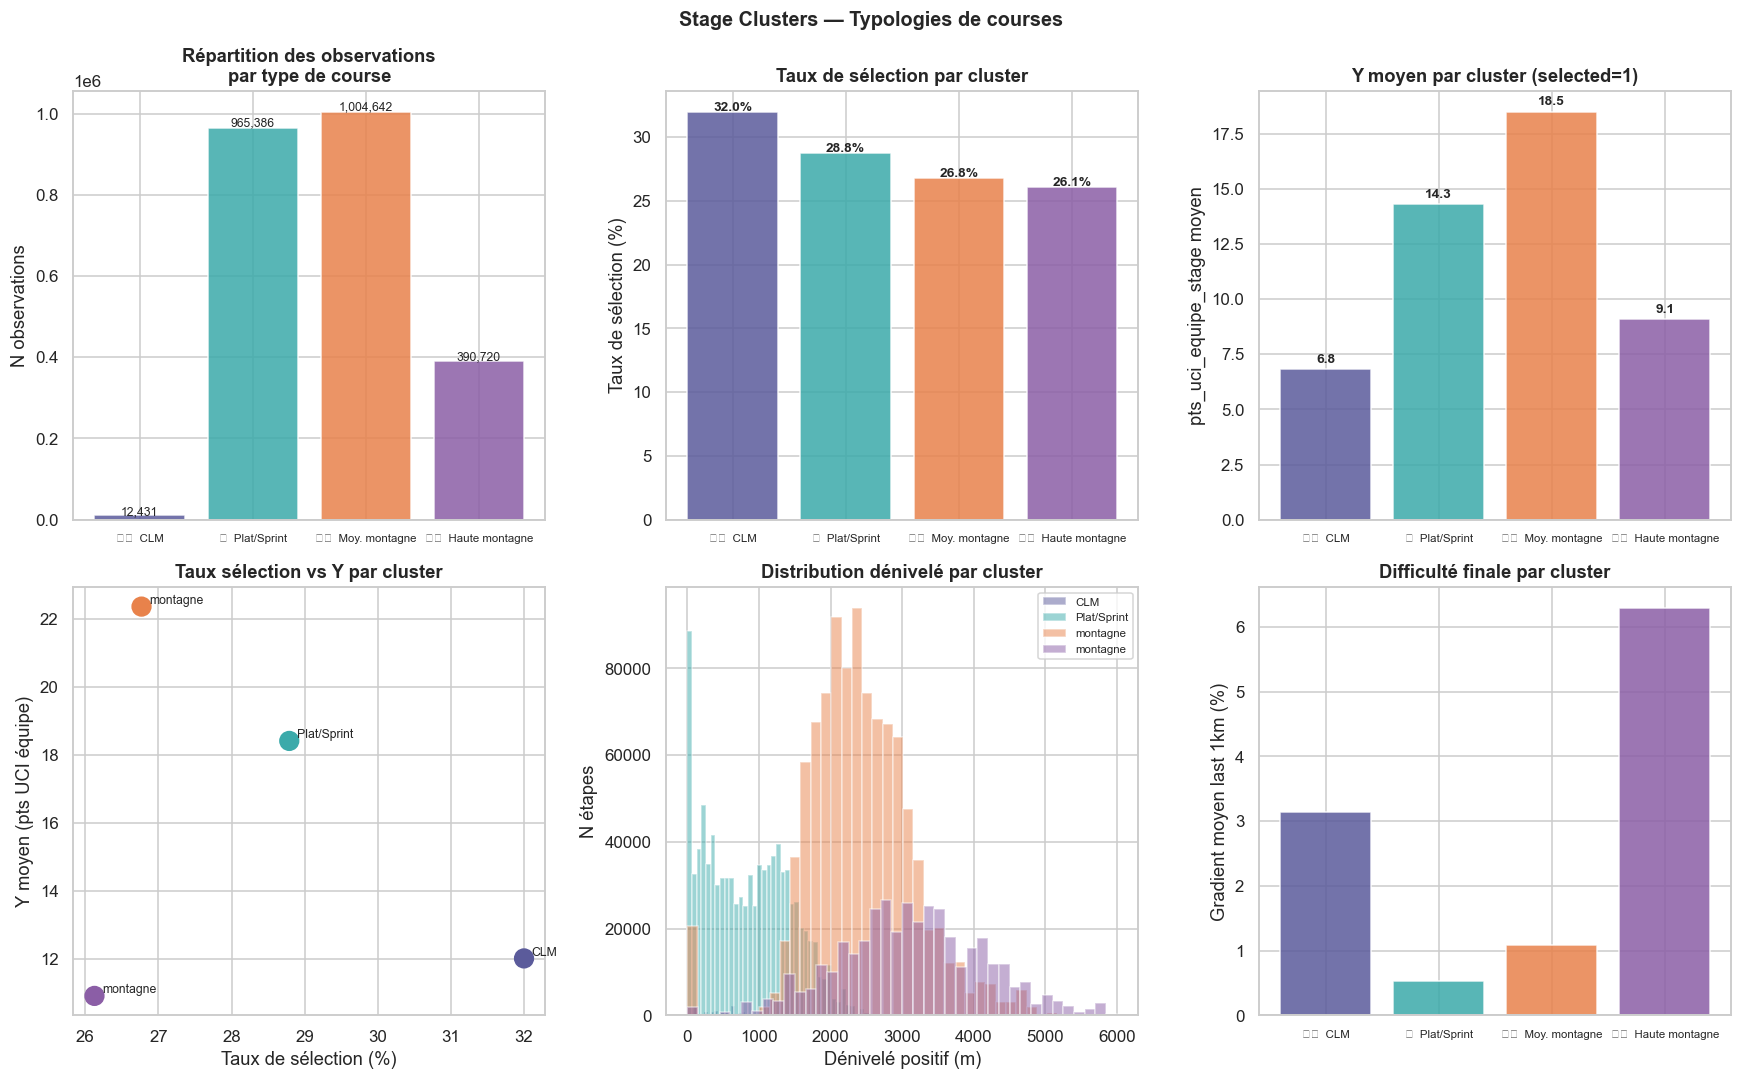

In [32]:
if 'stage_cluster_label' in df_all.columns:
    order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    ax = axes[0, 0]
    counts = df_all['stage_cluster_label'].value_counts().reindex(
        [c for c in order if c in df_all['stage_cluster_label'].values])
    cols_cl = [CLUSTER_COLORS.get(c, C_GRAY) for c in counts.index]
    ax.bar(range(len(counts)), counts.values, color=cols_cl, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, fontsize=7.5)
    ax.set_ylabel('N observations')
    ax.set_title('Répartition des observations\npar type de course', fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(i, v * 1.005, f'{v:,}', ha='center', fontsize=8)

    ax = axes[0, 1]
    taux_cl = df_all.groupby('stage_cluster_label')[TREATMENT].mean() * 100
    taux_cl = taux_cl.reindex([c for c in order if c in taux_cl.index])
    ax.bar(range(len(taux_cl)), taux_cl.values,
           color=[CLUSTER_COLORS.get(c, C_GRAY) for c in taux_cl.index],
           edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(taux_cl)))
    ax.set_xticklabels(taux_cl.index, fontsize=7.5)
    ax.set_ylabel('Taux de sélection (%)')
    ax.set_title('Taux de sélection par cluster', fontweight='bold')
    for i, v in enumerate(taux_cl.values):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

    ax = axes[0, 2]
    Y_cl = df_all[df_all[TREATMENT]==1].groupby('stage_cluster_label')[OUTCOME].mean()
    Y_cl = Y_cl.reindex([c for c in order if c in Y_cl.index])
    ax.bar(range(len(Y_cl)), Y_cl.values,
           color=[CLUSTER_COLORS.get(c, C_GRAY) for c in Y_cl.index],
           edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(Y_cl)))
    ax.set_xticklabels(Y_cl.index, fontsize=7.5)
    ax.set_ylabel('pts_uci_equipe_stage moyen')
    ax.set_title('Y moyen par cluster (selected=1)', fontweight='bold')
    for i, v in enumerate(Y_cl.values):
        ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

    ax = axes[1, 0]
    Y_cl_all = df_all.groupby('stage_cluster_label')[OUTCOME].mean()
    Y_cl_all = Y_cl_all.reindex([c for c in order if c in Y_cl_all.index])
    sel_rate = df_all.groupby('stage_cluster_label')[TREATMENT].mean()
    ax.scatter(sel_rate.reindex(Y_cl_all.index).values * 100, Y_cl_all.values,
               color=[CLUSTER_COLORS.get(c, C_GRAY) for c in Y_cl_all.index], s=150, zorder=3)
    for c, x, y in zip(Y_cl_all.index, sel_rate.reindex(Y_cl_all.index).values * 100, Y_cl_all.values):
        ax.annotate(c.split()[-1], (x, y), textcoords='offset points', xytext=(5, 2), fontsize=8)
    ax.set_xlabel('Taux de sélection (%)')
    ax.set_ylabel('Y moyen (pts UCI équipe)')
    ax.set_title('Taux sélection vs Y par cluster', fontweight='bold')

    ax = axes[1, 1]
    if 'denivele_pos' in df_all.columns:
        for c in [cl for cl in order if cl in df_all['stage_cluster_label'].values]:
            vals = df_all[df_all['stage_cluster_label']==c]['denivele_pos'].dropna().clip(0, 6000)
            ax.hist(vals, bins=40, alpha=0.5, label=c.split()[-1],
                    color=CLUSTER_COLORS.get(c, C_GRAY))
        ax.set_xlabel('Dénivelé positif (m)')
        ax.set_ylabel('N étapes')
        ax.set_title('Distribution dénivelé par cluster', fontweight='bold')
        ax.legend(fontsize=7.5)

    ax = axes[1, 2]
    if 'gradient_last_1km' in df_all.columns:
        grad_cl = df_all.groupby('stage_cluster_label')['gradient_last_1km'].mean()
        grad_cl = grad_cl.reindex([c for c in order if c in grad_cl.index])
        ax.bar(range(len(grad_cl)), grad_cl.values,
               color=[CLUSTER_COLORS.get(c, C_GRAY) for c in grad_cl.index],
               edgecolor='white', alpha=0.85)
        ax.set_xticks(range(len(grad_cl)))
        ax.set_xticklabels(grad_cl.index, fontsize=7.5)
        ax.set_ylabel('Gradient moyen last 1km (%)')
        ax.set_title('Difficulté finale par cluster', fontweight='bold')

    plt.suptitle('Stage Clusters — Typologies de courses', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 6.5 Niveau de compétition & conditions météo

`startlist_quality` (ProCyclingStats) mesure le niveau du plateau au départ — plus c'est élevé, plus la course est relevée (TDF ≈ 1500, course 2.2 ≈ 10–50). `avg_temperature` et `won_how` (type de victoire : solo, sprint de groupe, sprint réduit…) complètent le profil des conditions de course.

Ces variables sont des **confondants potentiels** : les meilleures équipes envoient leurs leaders sur les plus grandes courses → biais si non contrôlé.

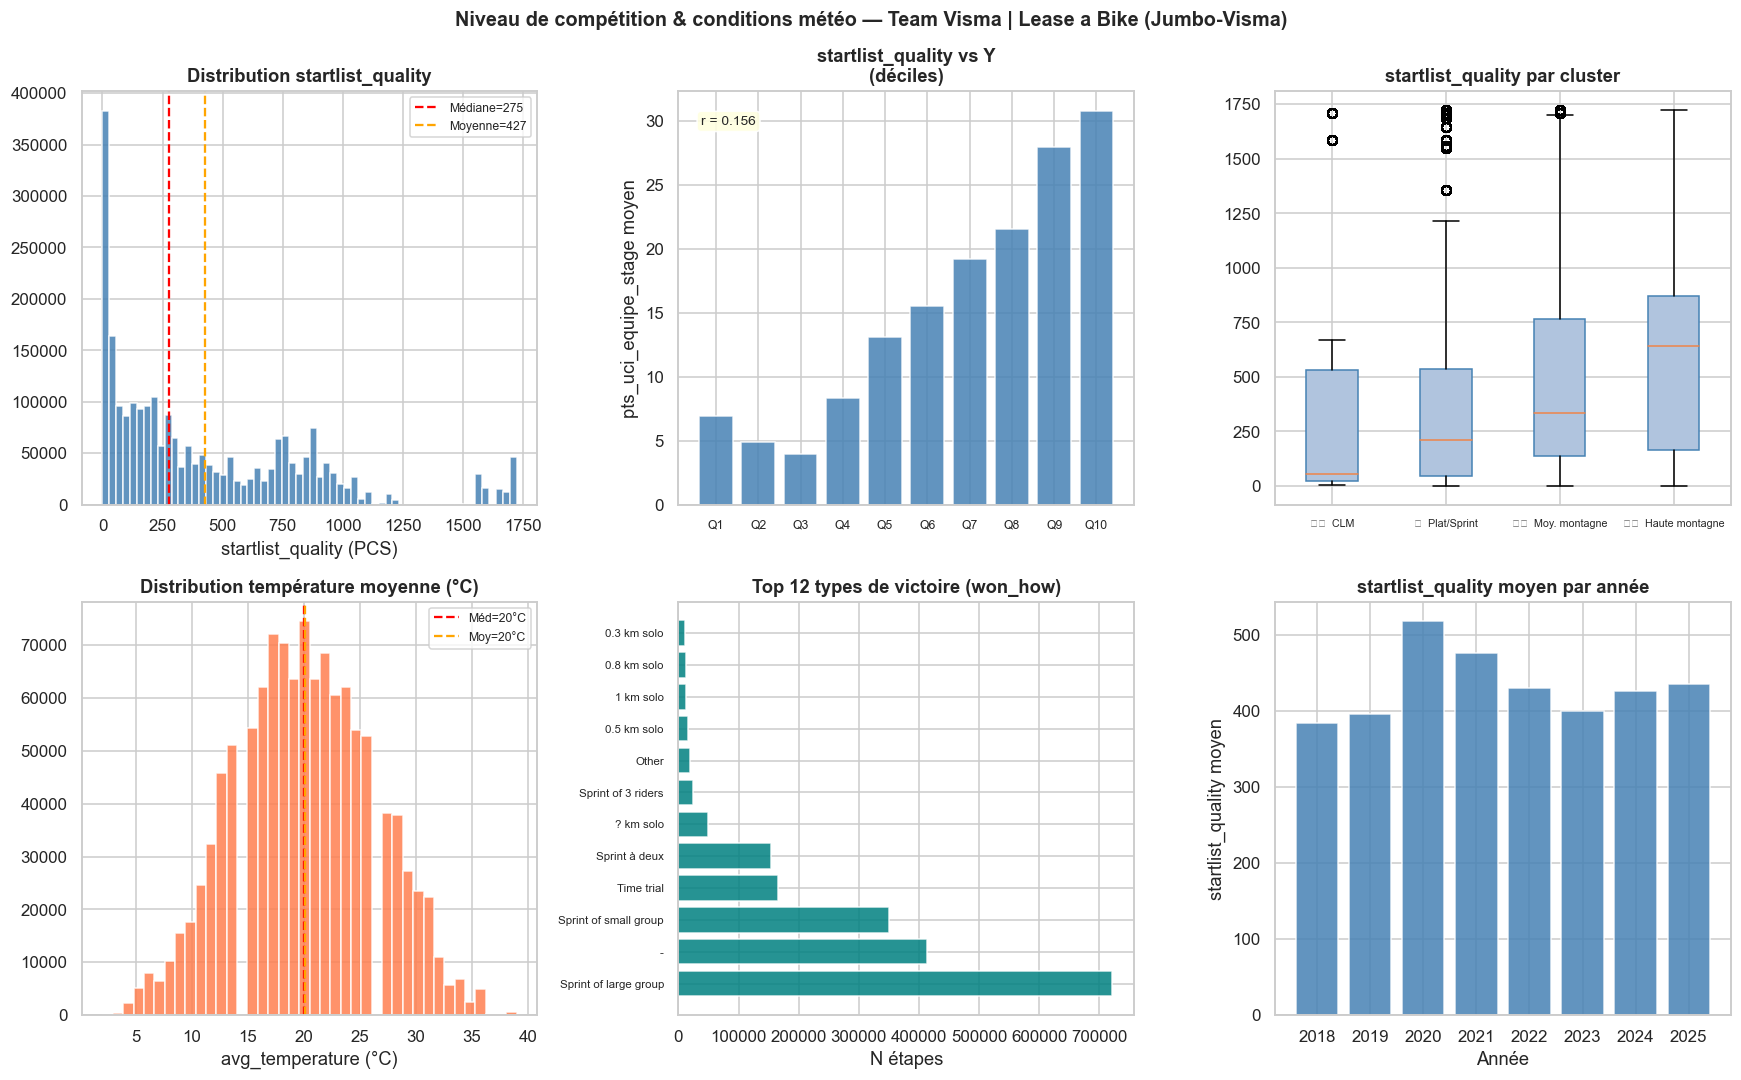

Corrélations startlist_quality :
  startlist_quality vs pts_uci_equipe_stage           : r = 0.1235
  startlist_quality vs selected                       : r = -0.1036
  startlist_quality vs forme_equipe                   : r = 0.1345


In [33]:
if 'startlist_quality' not in df_all.columns:
    print("⚠️  startlist_quality non disponible — lance d'abord les nouvelles cellules de form.ipynb")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # Distribution startlist_quality
    ax = axes[0,0]
    sq = df_all['startlist_quality'].dropna()
    ax.hist(sq, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(sq.median(), color='red',    linestyle='--', label=f'Médiane={sq.median():.0f}')
    ax.axvline(sq.mean(),   color='orange', linestyle='--', label=f'Moyenne={sq.mean():.0f}')
    ax.set_title('Distribution startlist_quality', fontweight='bold')
    ax.set_xlabel('startlist_quality (PCS)')
    ax.legend(fontsize=8)

    # startlist_quality vs Y (selected=1)
    ax = axes[0,1]
    sub_sq = df_all[df_all[TREATMENT]==1].dropna(subset=['startlist_quality', OUTCOME])
    sub_sq['sq_q'] = pd.qcut(sub_sq['startlist_quality'], q=10, duplicates='drop')
    sq_y = sub_sq.groupby('sq_q', observed=True)[OUTCOME].mean()
    ax.bar(range(len(sq_y)), sq_y.values, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(sq_y)))
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(sq_y))], fontsize=8)
    ax.set_ylabel('pts_uci_equipe_stage moyen')
    ax.set_title('startlist_quality vs Y\n(déciles)', fontweight='bold')
    r_sq = sub_sq[['startlist_quality', OUTCOME]].corr().iloc[0,1]
    ax.text(0.05, 0.92, f'r = {r_sq:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    # startlist_quality par cluster
    ax = axes[0,2]
    if 'stage_cluster_label' in df_all.columns:
        order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
        data_sq = [df_all[df_all['stage_cluster_label']==c]['startlist_quality'].dropna().values
                   for c in order if c in df_all['stage_cluster_label'].values]
        labels_sq = [c for c in order if c in df_all['stage_cluster_label'].values]
        ax.boxplot(data_sq, labels=labels_sq, patch_artist=True,
                   boxprops=dict(facecolor='lightsteelblue', color='steelblue'))
        ax.set_title('startlist_quality par cluster', fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

    # Distribution avg_temperature
    ax = axes[1,0]
    if 'avg_temperature' in df_all.columns:
        temp = df_all['avg_temperature'].dropna()
        ax.hist(temp, bins=40, color='coral', edgecolor='white', alpha=0.85)
        ax.axvline(temp.median(), color='red',    linestyle='--', label=f'Méd={temp.median():.0f}°C')
        ax.axvline(temp.mean(),   color='orange', linestyle='--', label=f'Moy={temp.mean():.0f}°C')
        ax.set_title('Distribution température moyenne (°C)', fontweight='bold')
        ax.set_xlabel('avg_temperature (°C)')
        ax.legend(fontsize=8)

    # Top won_how
    ax = axes[1,1]
    if 'won_how' in df_all.columns:
        wh = df_all['won_how'].dropna().value_counts().head(12)
        ax.barh(range(len(wh)), wh.values, color='teal', edgecolor='white', alpha=0.85)
        ax.set_yticks(range(len(wh)))
        ax.set_yticklabels(wh.index, fontsize=7.5)
        ax.set_xlabel('N étapes')
        ax.set_title('Top 12 types de victoire (won_how)', fontweight='bold')

    # startlist_quality par année
    ax = axes[1,2]
    sq_year = df_all.groupby('year')['startlist_quality'].mean()
    ax.bar(sq_year.index, sq_year.values, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title('startlist_quality moyen par année', fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel('startlist_quality moyen')

    plt.suptitle(f'Niveau de compétition & conditions météo — {EQUIPE_LABEL}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('Corrélations startlist_quality :')
    for col in [OUTCOME, TREATMENT, 'forme_equipe']:
        if col in df_all.columns:
            r = df_all[['startlist_quality', col]].dropna().corr().iloc[0,1]
            print(f'  startlist_quality vs {col:<30} : r = {r:.4f}')

## 7. Forme équipe & Charge coureur

Ces deux variables sont des **confondants importants** ajoutés à notre modèle :
- `forme_equipe` : moyenne des points UCI de l'équipe sur les 5 dernières courses du même type → capture l'état de forme collectif
- `n_races_30d` / `km_30d` : charge de course sur les 30 derniers jours → capture la fatigue individuelle

Elles ne sont pas dans les études précédentes (Rize et al., 2025) et constituent une contribution de ce travail.

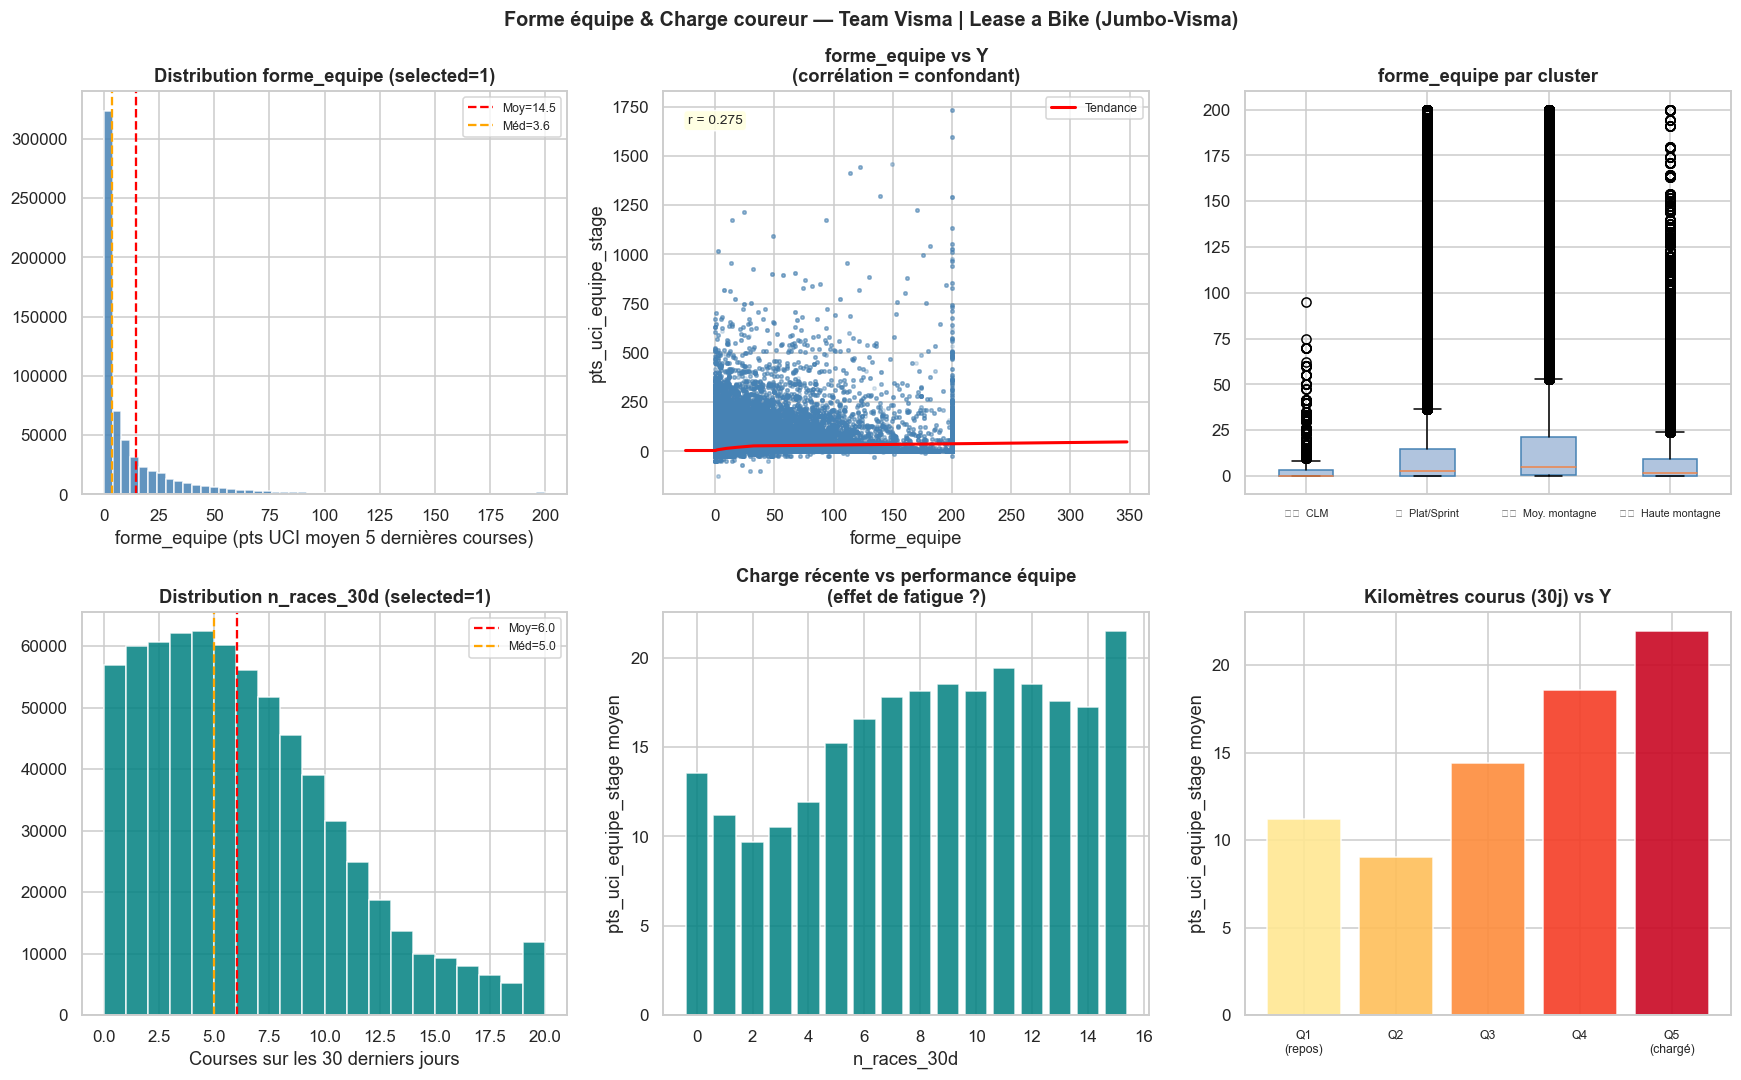

Corrélations avec Y :
  forme_equipe         : r = 0.2749
  n_races_30d          : r = 0.0605
  km_30d               : r = 0.0826


In [34]:
df_s1 = df_all[df_all[TREATMENT] == 1].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribution forme_equipe
ax = axes[0,0]
fe = df_s1['forme_equipe'].dropna().clip(0, 200)
ax.hist(fe, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(fe.mean(),   color='red',    linestyle='--', label=f'Moy={fe.mean():.1f}')
ax.axvline(fe.median(), color='orange', linestyle='--', label=f'Méd={fe.median():.1f}')
ax.set_title('Distribution forme_equipe (selected=1)', fontweight='bold')
ax.set_xlabel('forme_equipe (pts UCI moyen 5 dernières courses)')
ax.legend(fontsize=8)

# forme_equipe vs Y
ax = axes[0,1]
sub = df_s1.dropna(subset=['forme_equipe', OUTCOME])
ax.scatter(sub['forme_equipe'].clip(0,200), sub[OUTCOME],
           alpha=0.1, s=5, color='steelblue')
sub['fe_q'] = pd.qcut(sub['forme_equipe'], q=10, duplicates='drop')
trend = sub.groupby('fe_q')[OUTCOME].mean()
x_trend = [interval.mid for interval in trend.index.categories if hasattr(interval, 'mid')]
if x_trend:
    ax.plot(x_trend, trend.values, color='red', linewidth=2, label='Tendance')
ax.set_xlabel('forme_equipe')
ax.set_ylabel(OUTCOME)
ax.set_title('forme_equipe vs Y\n(corrélation = confondant)', fontweight='bold')
corr_fe = sub[['forme_equipe', OUTCOME]].corr().iloc[0,1]
ax.text(0.05, 0.92, f'r = {corr_fe:.3f}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax.legend(fontsize=8)

# forme_equipe par cluster
ax = axes[0,2]
if 'stage_cluster_label' in df_s1.columns:
    order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
    data_fe = [df_s1[df_s1['stage_cluster_label']==c]['forme_equipe'].dropna().clip(0,200).values
               for c in order if c in df_s1['stage_cluster_label'].values]
    labels_fe = [c for c in order if c in df_s1['stage_cluster_label'].values]
    ax.boxplot(data_fe, labels=labels_fe, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', color='steelblue'))
    ax.set_title('forme_equipe par cluster', fontweight='bold')
    ax.tick_params(axis='x', labelsize=7)

# Distribution n_races_30d
ax = axes[1,0]
nr = df_s1['n_races_30d'].dropna()
ax.hist(nr.clip(0, 20), bins=20, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(nr.mean(),   color='red',    linestyle='--', label=f'Moy={nr.mean():.1f}')
ax.axvline(nr.median(), color='orange', linestyle='--', label=f'Méd={nr.median():.1f}')
ax.set_title('Distribution n_races_30d (selected=1)', fontweight='bold')
ax.set_xlabel('Courses sur les 30 derniers jours')
ax.legend(fontsize=8)

# n_races_30d vs Y
ax = axes[1,1]
sub2 = df_s1.dropna(subset=['n_races_30d', OUTCOME])
charge_y = sub2.groupby(sub2['n_races_30d'].clip(0,15).astype(int))[OUTCOME].mean()
ax.bar(charge_y.index, charge_y.values, color='teal', edgecolor='white', alpha=0.85)
ax.set_xlabel('n_races_30d')
ax.set_ylabel('pts_uci_equipe_stage moyen')
ax.set_title('Charge récente vs performance équipe\n(effet de fatigue ?)', fontweight='bold')

# km_30d vs Y
ax = axes[1,2]
sub3 = df_s1.dropna(subset=['km_30d', OUTCOME])
sub3['km_q'] = pd.qcut(sub3['km_30d'], q=5, duplicates='drop',
                        labels=['Q1\n(repos)', 'Q2', 'Q3', 'Q4', 'Q5\n(chargé)'])
km_y = sub3.groupby('km_q', observed=True)[OUTCOME].mean()
colors_km = sns.color_palette('YlOrRd', len(km_y))
ax.bar(range(len(km_y)), km_y.values, color=colors_km, edgecolor='white', alpha=0.9)
ax.set_xticks(range(len(km_y)))
ax.set_xticklabels(km_y.index, fontsize=8)
ax.set_ylabel('pts_uci_equipe_stage moyen')
ax.set_title('Kilomètres courus (30j) vs Y', fontweight='bold')

plt.suptitle(f'Forme équipe & Charge coureur — {EQUIPE_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Corrélations avec Y :')
for col in ['forme_equipe', 'n_races_30d', 'km_30d']:
    if col in df_s1.columns:
        r = df_s1[[col, OUTCOME]].dropna().corr().iloc[0,1]
        print(f'  {col:<20} : r = {r:.4f}')

## 8. Vue par coureur — Top contributeurs

Statistiques résumées par coureur pour identifier les profils :
- Leaders (pts_uci individuels élevés)
- Domestiques clés (présence élevée, pts équipe bons)
- Spécialistes de terrain

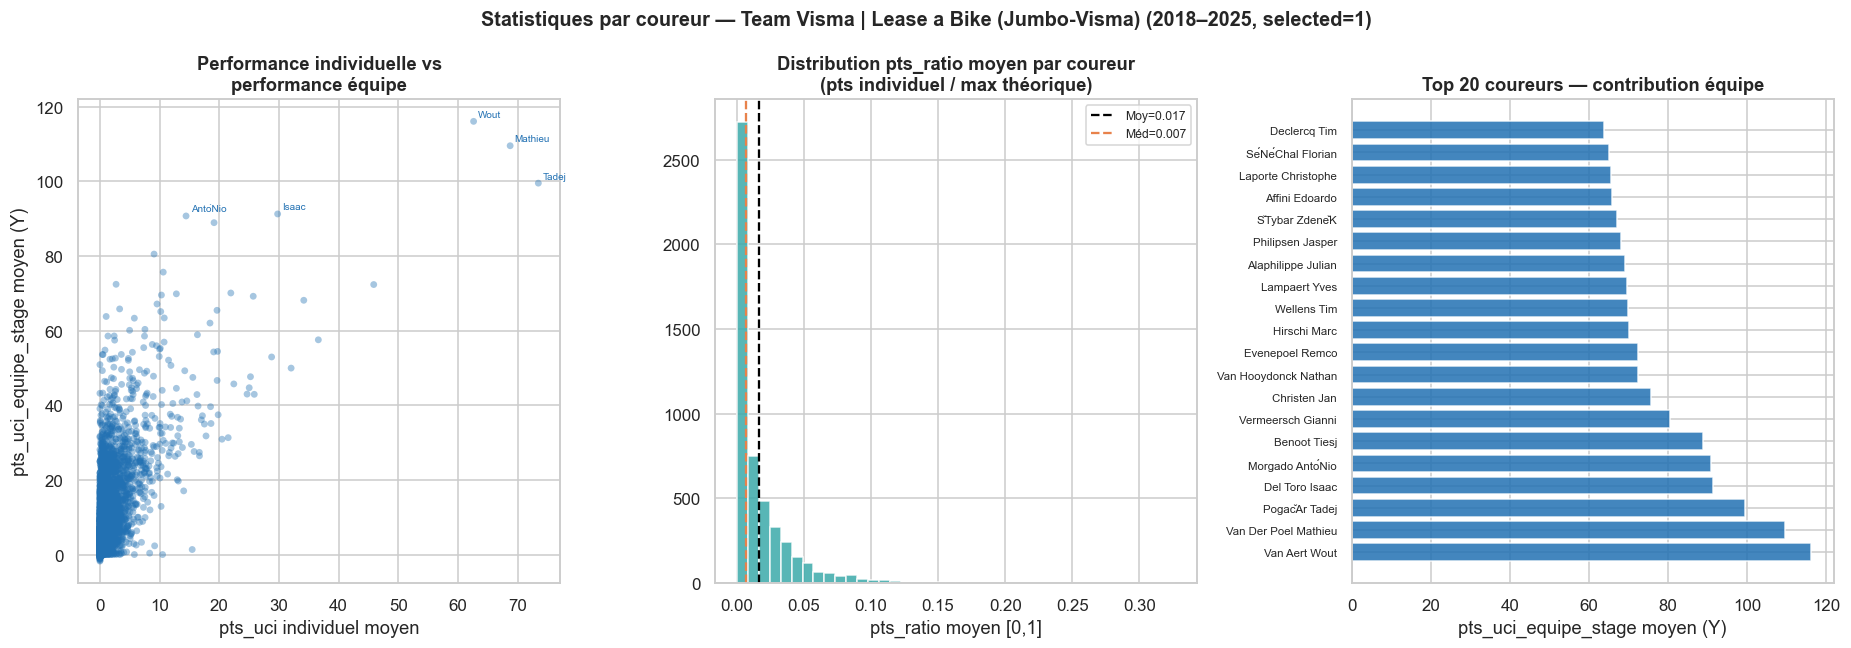

Top 15 coureurs — contribution équipe et points individuels :
               rider  n_sel  pts_uci_moy  pts_ratio_moy   Y_moy  n_years
       van_aert_wout    361       62.620          0.270 116.060        8
van_der_poel_mathieu    284       68.750          0.260 109.530        8
      pogačar_tadej    410       73.470          0.330  99.510        8
      del_toro_isaac    151       29.780          0.200  91.250        4
    morgado_antónio    116       14.430          0.090  90.720        3
        benoot_tiesj    422       19.120          0.060  88.920        8
   vermeersch_gianni    353        9.070          0.050  80.500        8
        christen_jan    146       10.610          0.080  75.660        3
van_hooydonck_nathan    306        2.710          0.010  72.410        6
     evenepoel_remco    359       45.880          0.250  72.340        7
        hirschi_marc    464       21.940          0.110  70.080        8
         wellens_tim    477       12.810          0.090  69.85

In [35]:
rider_full = df_all[df_all[TREATMENT]==1].groupby('rider').agg(
    n_sel         = (TREATMENT, 'count'),
    pts_uci_moy   = ('pts_uci', 'mean'),
    pts_ratio_moy = ('pts_ratio', lambda x: x.dropna().mean()),
    Y_moy         = (OUTCOME, 'mean'),
    Y_std         = (OUTCOME, 'std'),
    n_years       = ('year', 'nunique'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

ax = axes[0]
ax.scatter(rider_full['pts_uci_moy'].clip(0, 100), rider_full['Y_moy'],
           alpha=0.4, s=20, color=C_BLUE, edgecolors='none')
ax.set_xlabel('pts_uci individuel moyen')
ax.set_ylabel('pts_uci_equipe_stage moyen (Y)')
ax.set_title('Performance individuelle vs\nperformance équipe', fontweight='bold')
for _, row in rider_full.nlargest(5, 'Y_moy').iterrows():
    ax.annotate(row['rider'].replace('_', ' ').split()[-1].title(),
                (min(row['pts_uci_moy'], 100), row['Y_moy']),
                fontsize=6.5, xytext=(3, 3), textcoords='offset points', color=C_BLUE)

ax = axes[1]
pr = rider_full['pts_ratio_moy'].dropna()
ax.hist(pr.clip(0, 1), bins=40, color=C_TEAL, edgecolor='white', alpha=0.85)
ax.axvline(pr.mean(),   color='black', linestyle='--', label=f'Moy={pr.mean():.3f}')
ax.axvline(pr.median(), color=C_ORANGE, linestyle='--', label=f'Méd={pr.median():.3f}')
ax.set_title('Distribution pts_ratio moyen par coureur\n(pts individuel / max théorique)', fontweight='bold')
ax.set_xlabel('pts_ratio moyen [0,1]')
ax.legend(fontsize=8)

ax = axes[2]
top20 = rider_full.nlargest(20, 'Y_moy')
ax.barh(range(len(top20)), top20['Y_moy'].values, color=C_BLUE, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['rider'].str.replace('_', ' ').str.title(), fontsize=7.5)
ax.set_xlabel('pts_uci_equipe_stage moyen (Y)')
ax.set_title('Top 20 coureurs — contribution équipe', fontweight='bold')

plt.suptitle(f'Statistiques par coureur — {EQUIPE_LABEL} (2018–2025, selected=1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 15 coureurs — contribution équipe et points individuels :')
print(rider_full.nlargest(15, 'Y_moy')[['rider', 'n_sel', 'pts_uci_moy', 'pts_ratio_moy', 'Y_moy', 'n_years']]
      .round(2).to_string(index=False))


## 8.5 — Profil de sélection par type de course et niveau de compétition

Pour chaque coureur, on regarde **sur quels types d'étapes** il est sélectionné (répartition par cluster)
et **quel niveau de compétition** cible son équipe (startlist_quality moyen des courses jouées).


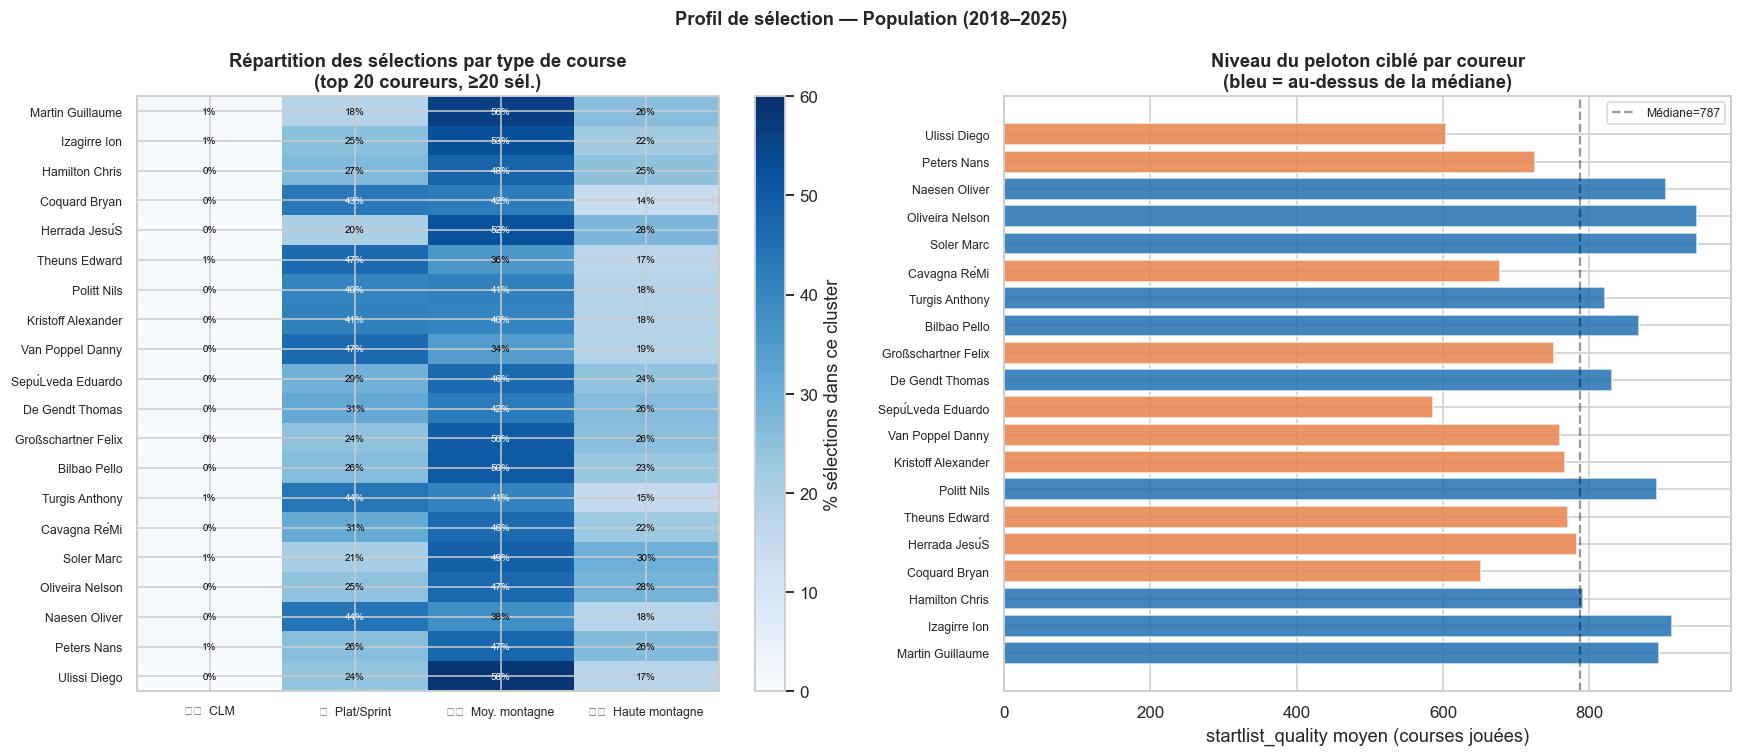

In [36]:
# ── Profil de sélection par cluster — heatmap ────────────────────────────────
sel_df = df_all[df_all[TREATMENT] == 1].copy()
MIN_SEL_DISPLAY = 20

top_riders_sel = (sel_df.groupby('rider').size()
                  .loc[lambda s: s >= MIN_SEL_DISPLAY]
                  .nlargest(20).index.tolist())

cluster_order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap : % sélections par cluster pour top 20 coureurs
ax = axes[0]
if 'stage_cluster_label' in sel_df.columns:
    hmap = (sel_df[sel_df['rider'].isin(top_riders_sel)]
            .groupby(['rider', 'stage_cluster_label']).size().unstack(fill_value=0))
    hmap = hmap.reindex(columns=[c for c in cluster_order if c in hmap.columns])
    hmap_pct = hmap.div(hmap.sum(axis=1), axis=0) * 100
    hmap_pct = hmap_pct.reindex(top_riders_sel, fill_value=0)

    im = ax.imshow(hmap_pct.values, aspect='auto', cmap='Blues', vmin=0, vmax=60)
    ax.set_xticks(range(len(hmap_pct.columns)))
    ax.set_xticklabels(hmap_pct.columns, fontsize=8)
    ax.set_yticks(range(len(hmap_pct)))
    ax.set_yticklabels([r.replace('_', ' ').title() for r in hmap_pct.index], fontsize=8)
    plt.colorbar(im, ax=ax, label='% sélections dans ce cluster')
    ax.set_title('Répartition des sélections par type de course\n(top 20 coureurs, ≥20 sél.)',
                 fontweight='bold')
    for i in range(len(hmap_pct)):
        for j in range(len(hmap_pct.columns)):
            v = hmap_pct.values[i, j]
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=6.5, color='white' if v > 38 else 'black')

# Startlist quality moyen des courses jouées
ax = axes[1]
if 'startlist_quality' in sel_df.columns:
    sq_mean = (sel_df[sel_df['rider'].isin(top_riders_sel)]
               .groupby('rider')['startlist_quality'].mean()
               .reindex(top_riders_sel))
    med_sq = sq_mean.median()
    colors_sq = [C_BLUE if v >= med_sq else C_ORANGE for v in sq_mean.values]
    ax.barh(range(len(sq_mean)), sq_mean.values, color=colors_sq, edgecolor='white', alpha=0.85)
    ax.axvline(med_sq, color='black', linestyle='--', alpha=0.4,
               label=f'Médiane={med_sq:.0f}')
    ax.set_yticks(range(len(sq_mean)))
    ax.set_yticklabels([r.replace('_', ' ').title() for r in sq_mean.index], fontsize=8)
    ax.set_xlabel('startlist_quality moyen (courses jouées)')
    ax.set_title('Niveau du peloton ciblé par coureur\n(bleu = au-dessus de la médiane)',
                 fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Profil de sélection — Population (2018–2025)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.7 — Meilleurs et pires contributeurs UCI

On filtre sur **≥ 20 sélections** pour exclure les jeunes sans historique stable.
`Y_moy` = pts UCI équipe moyen sur les étapes jouées.


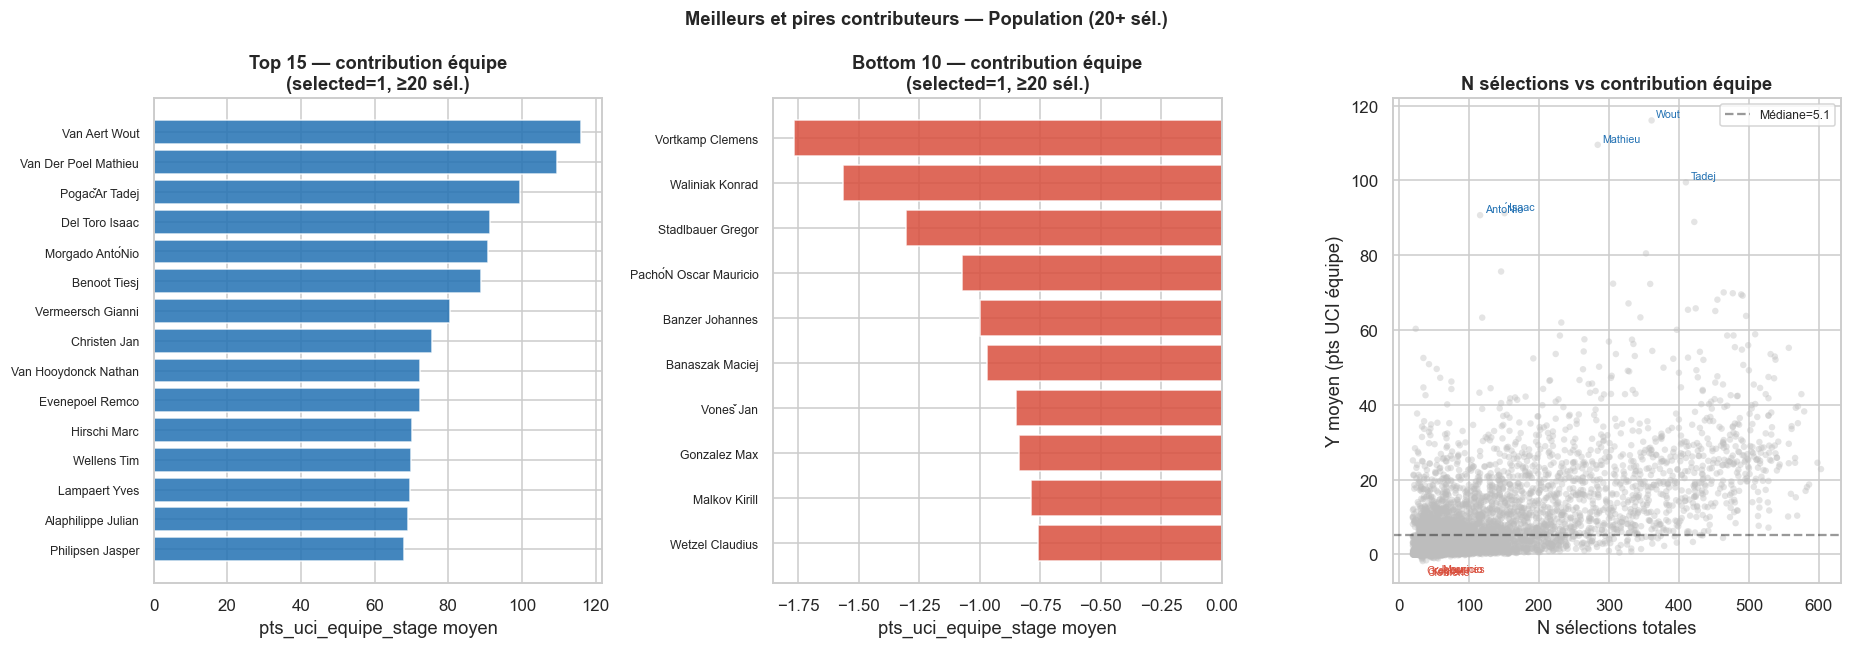

Top 10 (≥20 sél.) :
               rider  n_sel   Y_moy  pts_uci_moy  pts_ratio_moy   sq_moy  n_years
       van_aert_wout    361 116.060       62.620          0.270 1069.390        8
van_der_poel_mathieu    284 109.530       68.750          0.260  906.240        8
      pogačar_tadej    410  99.510       73.470          0.330  947.190        8
      del_toro_isaac    151  91.250       29.780          0.200  612.190        4
    morgado_antónio    116  90.720       14.430          0.090  376.380        3
        benoot_tiesj    422  88.920       19.120          0.060 1054.570        8
   vermeersch_gianni    353  80.500        9.070          0.050  709.190        8
        christen_jan    146  75.660       10.610          0.080  428.500        3
van_hooydonck_nathan    306  72.410        2.710          0.010  763.150        6
     evenepoel_remco    359  72.340       45.880          0.250  742.110        7

Bottom 10 (≥20 sél.) :
                 rider  n_sel  Y_moy  pts_uci_moy  sq_

In [37]:
# ── Meilleurs et pires contributeurs (selected=1, ≥ 20 sélections) ──────────
MIN_SEL = 20

rf = df_all[df_all[TREATMENT] == 1].groupby('rider').agg(
    n_sel         = (TREATMENT, 'count'),
    Y_moy         = (OUTCOME, 'mean'),
    pts_uci_moy   = ('pts_uci', 'mean'),
    pts_ratio_moy = ('pts_ratio', lambda x: x.dropna().mean()),
    sq_moy        = ('startlist_quality', lambda x: x.dropna().mean()),
    n_years       = ('year', 'nunique'),
).reset_index()
rf = rf[rf['n_sel'] >= MIN_SEL].dropna(subset=['Y_moy'])

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# Top 15
ax = axes[0]
top15 = rf.nlargest(15, 'Y_moy').sort_values('Y_moy', ascending=True)
ax.barh(range(len(top15)), top15['Y_moy'], color=C_BLUE, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['rider'].str.replace('_', ' ').str.title(), fontsize=8)
ax.set_xlabel('pts_uci_equipe_stage moyen')
ax.set_title(f'Top 15 — contribution équipe\n(selected=1, ≥{MIN_SEL} sél.)', fontweight='bold')

# Bottom 10
ax = axes[1]
bot10 = rf.nsmallest(10, 'Y_moy').sort_values('Y_moy', ascending=False)
ax.barh(range(len(bot10)), bot10['Y_moy'], color=C_RED, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(bot10)))
ax.set_yticklabels(bot10['rider'].str.replace('_', ' ').str.title(), fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('pts_uci_equipe_stage moyen')
ax.set_title(f'Bottom 10 — contribution équipe\n(selected=1, ≥{MIN_SEL} sél.)', fontweight='bold')

# Scatter N sel vs Y_moy
ax = axes[2]
ax.scatter(rf['n_sel'], rf['Y_moy'], color=C_GRAY, alpha=0.4, s=18, edgecolors='none')
for _, row in rf.nlargest(5, 'Y_moy').iterrows():
    ax.annotate(row['rider'].split('_')[-1].title(),
                (row['n_sel'], row['Y_moy']), textcoords='offset points',
                xytext=(3, 2), fontsize=7, color=C_BLUE)
for _, row in rf.nsmallest(5, 'Y_moy').iterrows():
    ax.annotate(row['rider'].split('_')[-1].title(),
                (row['n_sel'], row['Y_moy']), textcoords='offset points',
                xytext=(3, -9), fontsize=7, color=C_RED)
ax.axhline(rf['Y_moy'].median(), color='black', linestyle='--', alpha=0.4,
           label=f'Médiane={rf["Y_moy"].median():.1f}')
ax.set_xlabel('N sélections totales')
ax.set_ylabel('Y moyen (pts UCI équipe)')
ax.set_title('N sélections vs contribution équipe', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle(f'Meilleurs et pires contributeurs — Population ({MIN_SEL}+ sél.)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Top 10 (≥{MIN_SEL} sél.) :')
print(rf.nlargest(10, 'Y_moy')[['rider', 'n_sel', 'Y_moy', 'pts_uci_moy', 'pts_ratio_moy', 'sq_moy', 'n_years']].round(2).to_string(index=False))
print(f'\nBottom 10 (≥{MIN_SEL} sél.) :')
print(rf.nsmallest(10, 'Y_moy')[['rider', 'n_sel', 'Y_moy', 'pts_uci_moy', 'sq_moy']].round(2).to_string(index=False))


## 8.9 — Analyse descriptive du leader (`leader_played`)

`leader_played = 1` indique qu'un leader désigné de l'équipe participait à la course.
Disponible pour 2018–2023 uniquement (gap données sources pour 2024–2025).


Couverture leader_played : 97.0% des sélections
Taux de présence avec leader (selected=1) : 43.0%


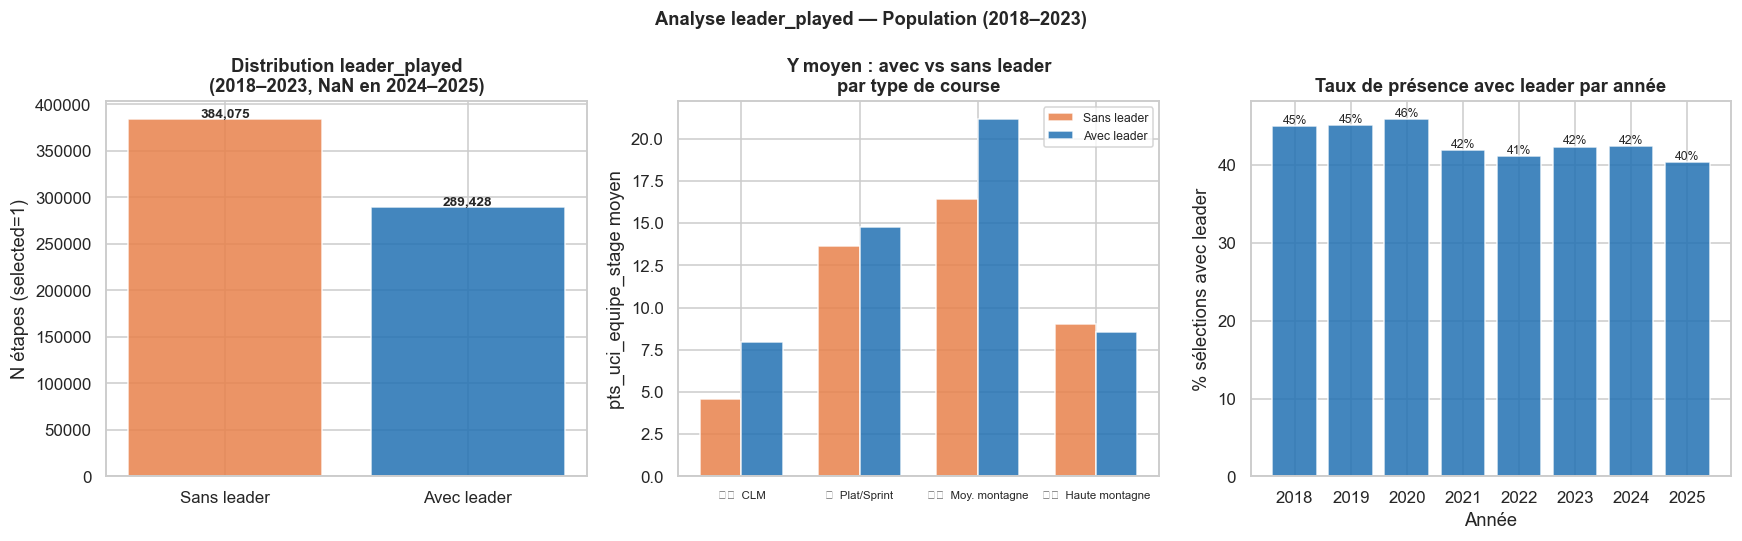

In [38]:
# ── Analyse descriptive leader_played ───────────────────────────────────────
if 'leader_played' not in df_all.columns or df_all['leader_played'].isna().all():
    print('⚠️  leader_played non disponible — relancer cell-load')
else:
    df_lp = df_all[df_all[TREATMENT] == 1].copy()
    df_lp['leader_played'] = pd.to_numeric(df_lp['leader_played'], errors='coerce')
    pct_lp = df_lp['leader_played'].mean() * 100

    print(f'Couverture leader_played : {df_lp["leader_played"].notna().mean()*100:.1f}% des sélections')
    print(f'Taux de présence avec leader (selected=1) : {pct_lp:.1f}%')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    counts_lp = df_lp['leader_played'].value_counts()
    ax.bar([0, 1], [counts_lp.get(0, 0), counts_lp.get(1, 0)],
           color=[C_ORANGE, C_BLUE], edgecolor='white', alpha=0.85)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sans leader', 'Avec leader'])
    ax.set_ylabel('N étapes (selected=1)')
    ax.set_title('Distribution leader_played\n(2018–2023, NaN en 2024–2025)', fontweight='bold')
    for x, n in zip([0, 1], [counts_lp.get(0, 0), counts_lp.get(1, 0)]):
        ax.text(x, n * 1.005, f'{n:,}', ha='center', fontsize=9, fontweight='bold')

    ax = axes[1]
    if 'stage_cluster_label' in df_lp.columns:
        cluster_order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
        cl_lp = (df_lp.dropna(subset=['leader_played'])
                 .groupby(['stage_cluster_label', 'leader_played'])[OUTCOME].mean().unstack())
        cl_lp = cl_lp.reindex([c for c in cluster_order if c in cl_lp.index])
        x_c = np.arange(len(cl_lp))
        w = 0.35
        if 0.0 in cl_lp.columns:
            ax.bar(x_c - w/2, cl_lp[0.0].fillna(0), w, label='Sans leader',
                   color=C_ORANGE, edgecolor='white', alpha=0.85)
        if 1.0 in cl_lp.columns:
            ax.bar(x_c + w/2, cl_lp[1.0].fillna(0), w, label='Avec leader',
                   color=C_BLUE, edgecolor='white', alpha=0.85)
        ax.set_xticks(x_c)
        ax.set_xticklabels(cl_lp.index, fontsize=7.5)
        ax.set_ylabel('pts_uci_equipe_stage moyen')
        ax.set_title('Y moyen : avec vs sans leader\npar type de course', fontweight='bold')
        ax.legend(fontsize=8)

    ax = axes[2]
    lp_year = (df_lp.dropna(subset=['leader_played'])
               .groupby('year')['leader_played'].mean() * 100)
    ax.bar(lp_year.index.astype(int), lp_year.values, color=C_BLUE, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Année')
    ax.set_ylabel('% sélections avec leader')
    ax.set_title('Taux de présence avec leader par année', fontweight='bold')
    for y, v in zip(lp_year.index.astype(int), lp_year.values):
        ax.text(y, v + 0.3, f'{v:.0f}%', ha='center', fontsize=8)

    plt.suptitle('Analyse leader_played — Population (2018–2023)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 9. Zoom sur un coureur — Analyse individuelle

Choisir un coureur ci-dessous pour afficher son profil complet :
timeline des performances, répartition par type de course, meilleures/pires courses.


In [39]:
# ── Choisir le coureur à analyser ────────────────────────────────────────────
# Format : nom_prenom (nom du fichier CSV dans rider_data/, sans .csv)

RIDER_FOCUS = 'van_aert_wout'

focus_path = RIDER_DIR / f'{RIDER_FOCUS}.csv'
if focus_path.exists():
    print(f'✅  {RIDER_FOCUS}  →  {focus_path}')
else:
    # Suggestions si nom mal orthographié
    first = RIDER_FOCUS.split('_')[0]
    matches = sorted(RIDER_DIR.glob(f'*{first}*.csv'))
    print(f'❌  {RIDER_FOCUS} non trouvé.')
    if matches:
        print('Suggestions :')
        for m in matches[:6]:
            print(f'   {m.stem}')


✅  van_aert_wout  →  rider_data/van_aert_wout.csv


=== Van Aert Wout ===
Observations : 1,711 total | 361 sélections (21.1%)
Années       : 2018–2025
Équipes      : Vérandas Willems-Crelan, Belgium, Team Jumbo-Visma, Jumbo-Visma, Team Visma | Lease a Bike
pts UCI total (individuel)   : 22,606
Y moyen (pts équipe/étape)   : 116.06
Y max                        : 1290


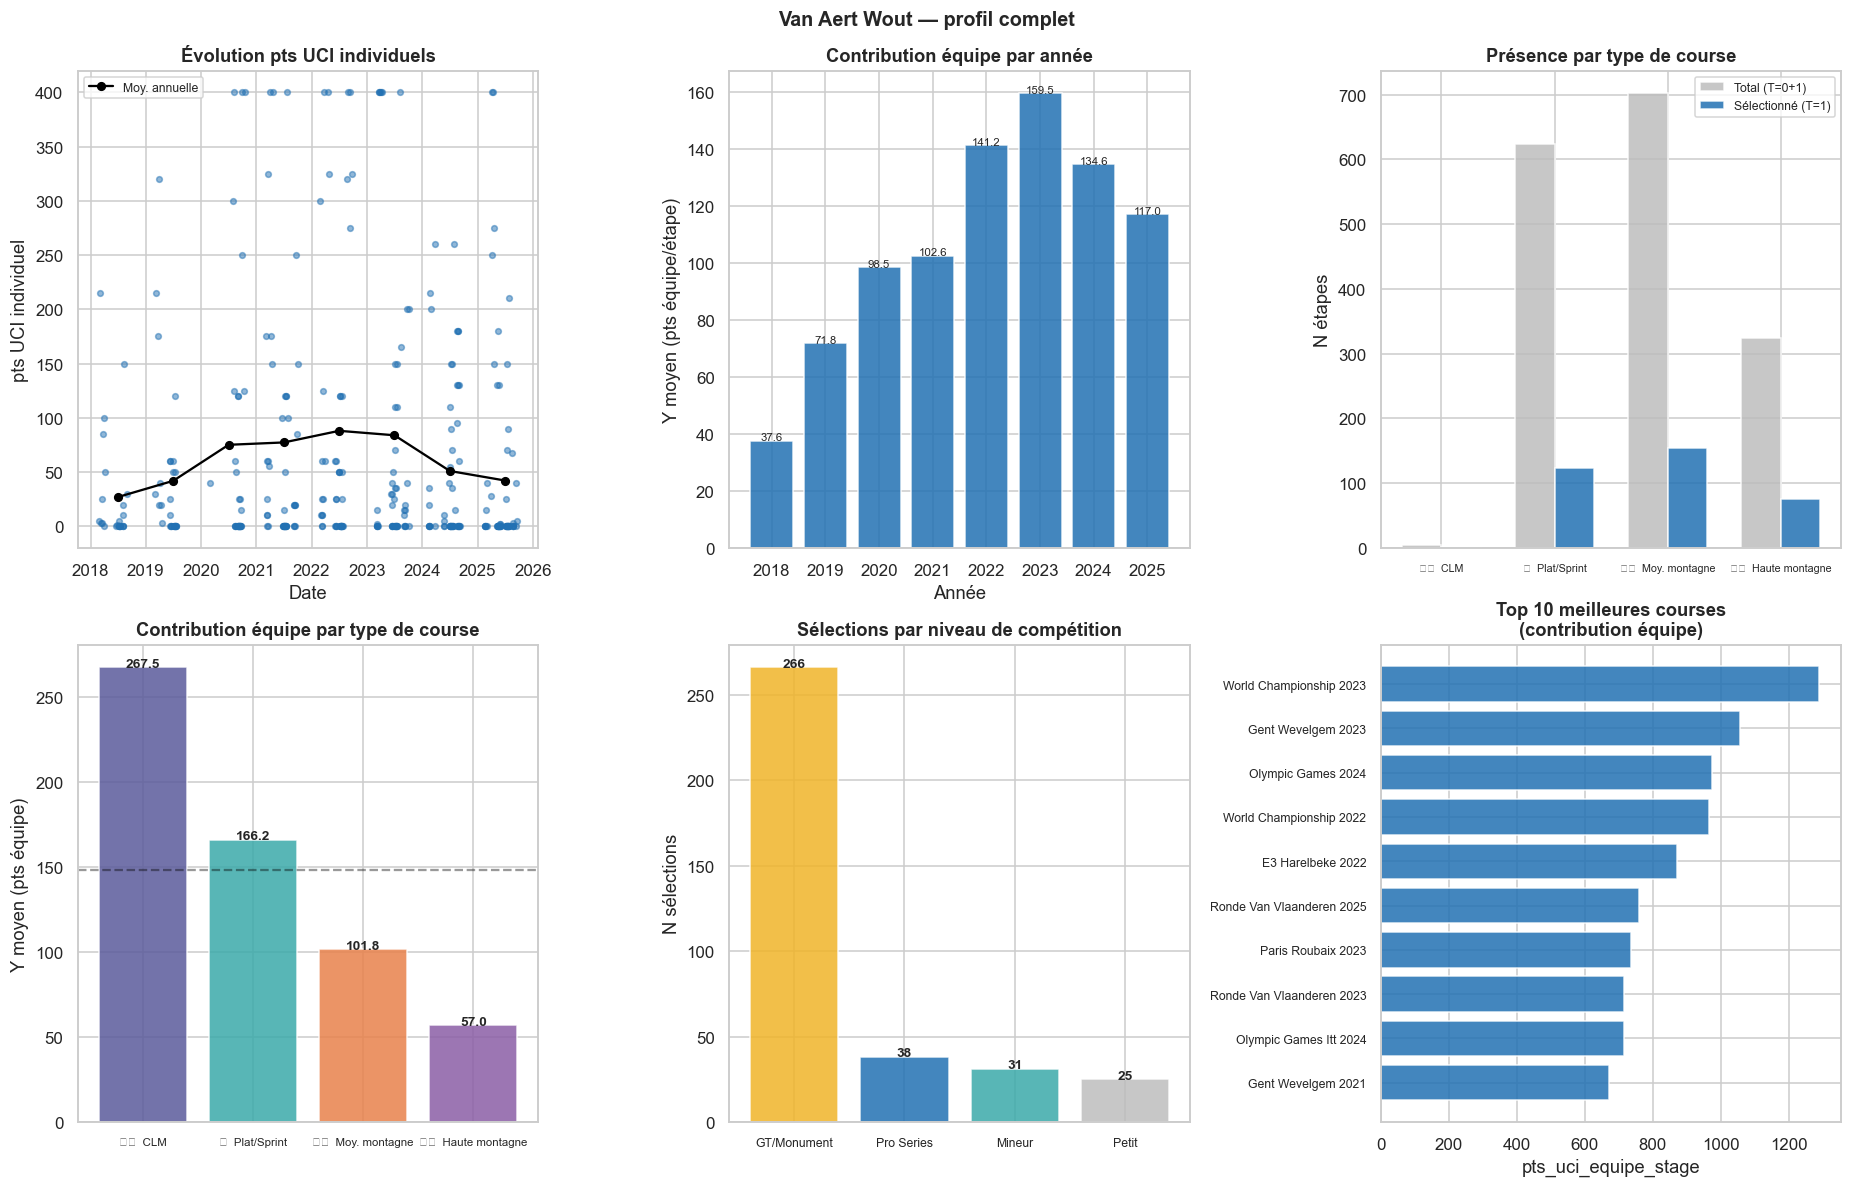


Top 10 meilleures courses :
      date               course  year stage_cluster_label  pts_uci  pts_uci_equipe_stage   rang  startlist_quality
2023-08-06   world-championship  2023      🟢  Plat/Sprint  715.000              1290.000  2.000           1113.000
2023-03-26        gent-wevelgem  2023      🟢  Plat/Sprint  400.000              1055.000  2.000            897.000
2024-08-03        olympic-games  2024   ⛰️  Moy. montagne   15.000               975.000 37.000            964.000
2022-09-25   world-championship  2022   ⛰️  Moy. montagne  325.000               965.000  4.000           1052.000
2022-03-25         e3-harelbeke  2022      🟢  Plat/Sprint  400.000               872.000  1.000            608.000
2025-04-06 ronde-van-vlaanderen  2025      🟢  Plat/Sprint  440.000               760.000  4.000            819.000
2023-04-09        paris-roubaix  2023      🟢  Plat/Sprint  520.000               735.000  3.000            775.000
2023-04-02 ronde-van-vlaanderen  2023      🟢  Plat/

In [40]:
# ── Analyse individuelle ──────────────────────────────────────────────────────
focus_path = RIDER_DIR / f'{RIDER_FOCUS}.csv'
if not focus_path.exists():
    print(f'❌  {RIDER_FOCUS} non trouvé — modifie RIDER_FOCUS dans la cellule précédente')
else:
    df_f = pd.read_csv(focus_path, low_memory=False)
    df_f['date'] = pd.to_datetime(df_f['date'], errors='coerce')
    df_f['year'] = pd.to_numeric(df_f['year'], errors='coerce')
    df_f[OUTCOME]     = pd.to_numeric(df_f[OUTCOME],     errors='coerce')
    df_f['pts_uci']   = pd.to_numeric(df_f['pts_uci'],   errors='coerce')
    df_f[TREATMENT]   = pd.to_numeric(df_f[TREATMENT],   errors='coerce')

    df_sf = df_f[df_f[TREATMENT] == 1].copy()
    years = sorted(df_f['year'].dropna().unique().astype(int))
    equipes = df_f['equipe'].dropna().unique() if 'equipe' in df_f.columns else []

    print(f'=== {RIDER_FOCUS.replace("_", " ").title()} ===')
    print(f'Observations : {len(df_f):,} total | {len(df_sf):,} sélections ({len(df_sf)/len(df_f)*100:.1f}%)')
    print(f'Années       : {years[0]}–{years[-1]}')
    print(f'Équipes      : {", ".join(equipes[:5])}')
    print(f'pts UCI total (individuel)   : {df_sf["pts_uci"].sum():,.0f}')
    print(f'Y moyen (pts équipe/étape)   : {df_sf[OUTCOME].mean():.2f}')
    print(f'Y max                        : {df_sf[OUTCOME].max():.0f}')

    cluster_order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']

    fig, axes = plt.subplots(2, 3, figsize=(17, 11))

    # 1. Timeline pts_uci individuel
    ax = axes[0, 0]
    ax.scatter(df_sf['date'], df_sf['pts_uci'].clip(0, 400),
               color=C_BLUE, alpha=0.5, s=14)
    pts_yr = df_sf.groupby('year')['pts_uci'].mean()
    ax.plot(pd.to_datetime(pts_yr.index.astype(str) + '-07-01'), pts_yr.values,
            'o-', color='black', linewidth=1.5, markersize=5, label='Moy. annuelle')
    ax.set_xlabel('Date')
    ax.set_ylabel('pts UCI individuel')
    ax.set_title('Évolution pts UCI individuels', fontweight='bold')
    ax.legend(fontsize=8)

    # 2. Contribution équipe par année
    ax = axes[0, 1]
    Y_yr = df_sf.groupby('year')[OUTCOME].mean()
    ax.bar(Y_yr.index.astype(int), Y_yr.values, color=C_BLUE, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Année')
    ax.set_ylabel('Y moyen (pts équipe/étape)')
    ax.set_title('Contribution équipe par année', fontweight='bold')
    for y, v in zip(Y_yr.index.astype(int), Y_yr.values):
        ax.text(y, v + 0.2, f'{v:.1f}', ha='center', fontsize=7.5)

    # 3. Présence par type de course
    ax = axes[0, 2]
    if 'stage_cluster_label' in df_f.columns:
        cnt_all = df_f['stage_cluster_label'].value_counts().reindex(
            [c for c in cluster_order if c in df_f['stage_cluster_label'].values], fill_value=0)
        cnt_sel = df_sf['stage_cluster_label'].value_counts().reindex(cnt_all.index, fill_value=0)
        x_cl = np.arange(len(cnt_all))
        w = 0.35
        ax.bar(x_cl - w/2, cnt_all.values, w, label='Total (T=0+1)',
               color=C_GRAY, edgecolor='white', alpha=0.85)
        ax.bar(x_cl + w/2, cnt_sel.values, w, label='Sélectionné (T=1)',
               color=C_BLUE, edgecolor='white', alpha=0.85)
        ax.set_xticks(x_cl)
        ax.set_xticklabels(cnt_all.index, fontsize=7)
        ax.set_ylabel('N étapes')
        ax.set_title('Présence par type de course', fontweight='bold')
        ax.legend(fontsize=8)

    # 4. Y moyen par cluster
    ax = axes[1, 0]
    if 'stage_cluster_label' in df_sf.columns:
        Y_cl = df_sf.groupby('stage_cluster_label')[OUTCOME].mean()
        Y_cl = Y_cl.reindex([c for c in cluster_order if c in Y_cl.index])
        ax.bar(range(len(Y_cl)), Y_cl.values,
               color=[CLUSTER_COLORS.get(c, C_GRAY) for c in Y_cl.index],
               edgecolor='white', alpha=0.85)
        ax.set_xticks(range(len(Y_cl)))
        ax.set_xticklabels(Y_cl.index, fontsize=7.5)
        ax.axhline(Y_cl.mean(), color='black', linestyle='--', alpha=0.4)
        ax.set_ylabel('Y moyen (pts équipe)')
        ax.set_title('Contribution équipe par type de course', fontweight='bold')
        for i, v in enumerate(Y_cl.values):
            ax.text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

    # 5. Sélections par niveau de compétition
    ax = axes[1, 1]
    if 'startlist_quality' in df_sf.columns:
        def sq_tier(sq):
            if pd.isna(sq): return 'Inconnu'
            if sq >= 750: return 'GT/Monument'
            if sq >= 450: return 'Pro Series'
            if sq >= 200: return 'Mineur'
            return 'Petit'
        tier_order = ['GT/Monument', 'Pro Series', 'Mineur', 'Petit']
        tier_colors = {'GT/Monument': '#F0B429', 'Pro Series': C_BLUE,
                       'Mineur': C_TEAL, 'Petit': C_GRAY}
        df_sf = df_sf.copy()
        df_sf['tier'] = df_sf['startlist_quality'].apply(sq_tier)
        tier_cnt = df_sf['tier'].value_counts().reindex(
            [t for t in tier_order if t in df_sf['tier'].values], fill_value=0)
        ax.bar(range(len(tier_cnt)), tier_cnt.values,
               color=[tier_colors.get(t, C_GRAY) for t in tier_cnt.index],
               edgecolor='white', alpha=0.85)
        ax.set_xticks(range(len(tier_cnt)))
        ax.set_xticklabels(tier_cnt.index, fontsize=8)
        ax.set_ylabel('N sélections')
        ax.set_title('Sélections par niveau de compétition', fontweight='bold')
        for i, v in enumerate(tier_cnt.values):
            ax.text(i, v + 0.4, str(v), ha='center', fontsize=9, fontweight='bold')

    # 6. Top 10 meilleures courses
    ax = axes[1, 2]
    show_top = df_sf.nlargest(10, OUTCOME).copy()
    show_top['label'] = (show_top['course'].str.replace('-', ' ').str.title().str[:20]
                         + ' ' + show_top['year'].astype(int).astype(str))
    ax.barh(range(len(show_top)), show_top[OUTCOME].values[::-1],
            color=C_BLUE, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(show_top)))
    ax.set_yticklabels(show_top['label'].values[::-1], fontsize=8)
    ax.set_xlabel('pts_uci_equipe_stage')
    ax.set_title('Top 10 meilleures courses\n(contribution équipe)', fontweight='bold')

    plt.suptitle(f'{RIDER_FOCUS.replace("_", " ").title()} — profil complet',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    show_c = [c for c in ['date', 'course', 'year', 'stage_cluster_label',
                           'pts_uci', OUTCOME, 'rang', 'startlist_quality']
              if c in df_sf.columns]
    print(f'\nTop 10 meilleures courses :')
    print(df_sf.nlargest(10, OUTCOME)[show_c].to_string(index=False))
    print(f'\nBottom 5 courses (Y le plus faible) :')
    print(df_sf.nsmallest(5, OUTCOME)[show_c].to_string(index=False))


## Conclusion & Points clés pour la modélisation

**Ce qu'on retient de cette exploration :**

1. **Y (`pts_uci_equipe_stage`) est très asymétrique** avec ~XX% de zéros → utiliser `log(1+Y)` dans les modèles

2. **Le biais de sélection est clairement visible** : les coureurs sélectionnés vont sur des courses physiquement différentes de celles où ils sont absents → les effets bruts sont biaisés → nécessité du DML

3. **Les confondants clés** à contrôler dans le DML :
   - *Course* : distance, dénivelé, cols, gradient, surfaces (cobblestones)
   - *Équipe* : forme_equipe (5 dernières courses, même cluster)
   - *Coureur* : n_races_30d, km_30d (charge récente)

4. **Stage clusters** : 4 types de courses → permettent l'analyse de l'hétérogénéité des effets (CATE)

5. **Variance suffisante** dans T (sélection) pour la majorité des coureurs → DML applicable

→ **Prochaine étape** : `Modele_Causal.ipynb` — Double Machine Learning + Causal Forest